# Filtrado colaborativo con embeddings (NCF)

En este cuadernillo se construye un modelo de filtrado colaborativo basado en Neural Collaborative Filtering (NCF): una red neuronal que aprende un embedding para cada usuario y cada película, y predice el rating a partir de esos embeddings. El optimizador usado en este cuadernillo es SGD.

Fuentes:
- Curso de PyTorch de Datacamp
- https://www.geeksforgeeks.org/deep-learning/neural-collaborative-filtering/

In [1]:
import pandas as pd
import numpy as np

In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim
import random
import copy
import matplotlib.pyplot as plt

In [3]:
random.seed(73)
np.random.seed(73)
torch.manual_seed(73)
torch.cuda.manual_seed_all(73) #si hay gpu

Se fijan las semillas aleatorias para que el entrenamiento sea reproducible.

## Carga y preparación de datos

In [4]:
datosRedes = pd.read_parquet("../../data/02_processed/ratings_integrity.parquet")

Las capas de embedding de PyTorch necesitan índices consecutivos empezando en 0, y los IDs originales de usuarios y películas no lo son. Por eso se construye un diccionario que traduce cada userId y cada movieId a un índice consecutivo.

In [5]:
# Indices consecutivos para usuarios
userIndice = {}
i = 0

for user in datosRedes["userId"].unique():
    userIndice[user] = i
    i += 1

In [6]:
# índices consecutivos para películas
movieIndice = {}
i = 0

for movie in datosRedes["movieId"].unique():
    movieIndice[movie] = i
    i += 1

In [7]:
datosRedes["userIndice"] = datosRedes["userId"].map(userIndice)
datosRedes["movieIndice"] = datosRedes["movieId"].map(movieIndice)

In [8]:
datosRedes.sort_values('userId')

,userId,movieId,rating,timestamp,userIndice,movieIndice
0,1,1,4.0,2000-07-30 18:45:03,0,0
1,1,3,4.0,2000-07-30 18:20:47,0,1
2,1,6,4.0,2000-07-30 18:37:04,0,2
3,1,47,5.0,2000-07-30 19:03:35,0,3
4,1,50,5.0,2000-07-30 18:48:51,0,4
...,...,...,...,...,...,...
100500,610,166534,4.0,2017-05-03 21:53:22,609,3094
100501,610,168248,5.0,2017-05-03 22:21:31,609,2024
100502,610,168250,5.0,2017-05-08 19:50:47,609,3095
100503,610,168252,5.0,2017-05-03 21:19:12,609,1385


## Partición en train, val y test
Igual que en el resto de modelos, la partición se hace por usuario y de forma temporal: para cada usuario, sus valoraciones se ordenan por timestamp y se dividen en el primer 70% (train), el siguiente 15% (val) y el último 15% (test), evitando así fugas de información desde valoraciones futuras.

In [9]:
# PARTICIÓN TRAIN /VAL / TEST.
train = pd.DataFrame()
val   = pd.DataFrame()
test  = pd.DataFrame()


datosRedes = datosRedes.sort_values(['userId', 'timestamp'])

def particion(ratingsUser):
    global train, val, test
    n       = len(ratingsUser)
    p_train = round(n * 0.70)
    p_val   = round(n * 0.85)

    trainPar = ratingsUser.head(p_train)
    valPar   = ratingsUser.iloc[p_train:p_val]
    testPar  = ratingsUser.tail(n - p_val)

    train = pd.concat([train, trainPar], ignore_index=True)
    val   = pd.concat([val,   valPar],   ignore_index=True)
    test  = pd.concat([test,  testPar],  ignore_index=True)

for i in datosRedes['userId'].unique():
    particion(datosRedes[datosRedes['userId'] == i])

print(f"Train: {len(train)} ratings")
print(f"Val:   {len(val)} ratings")
print(f"Test:  {len(test)} ratings")

Train: 70342 ratings
Val:   15103 ratings
Test:  15060 ratings


## Preparación para PyTorch
Se escalan los ratings al rango [0, 1] (dividiendo entre 5), ya que la red termina con una sigmoide, cuya salida está en ese rango.

In [10]:
train['rating_norm'] = train['rating'] / 5.0
val['rating_norm']   = val['rating'] / 5.0
test['rating_norm']  = test['rating'] / 5.0

Se define un Dataset de PyTorch que, para cada valoración, devuelve el índice del usuario, el índice de la película y el rating normalizado.

In [11]:
class RedesDataSet(Dataset):
    def __init__(self,df):
        super().__init__()
        self.userInd = torch.tensor(df['userIndice'].values, dtype=torch.long)
        self.movieInd = torch.tensor(df['movieIndice'].values, dtype=torch.long)
        # self.X = torch.from_numpy(df[variables].values.astype(np.float32))
        self.y = torch.from_numpy(df['rating_norm'].values.astype(np.float32))
       
    def __getitem__(self, ind):
        return self.userInd[ind], self.movieInd[ind], self.y[ind]  #self.X[ind]
   
    def __len__(self):
        return self.y.shape[0]

Se crean los datasets y dataloaders de train, val y test. Además, dataset_train_val (y su dataloader) combina train y val, y se usará más adelante para reentrenar el modelo final con toda la información disponible antes de evaluar sobre test.

In [12]:
dataset_train = RedesDataSet(train)
dataset_val  = RedesDataSet(val)
dataset_test  = RedesDataSet(test)
dataset_train_val = RedesDataSet(pd.concat([train, val]))
dataloader_train= DataLoader(dataset_train, batch_size=200, shuffle=True)
dataloader_val   = DataLoader(dataset_val,   batch_size=200, shuffle=False)
dataloader_test  = DataLoader(dataset_test,  batch_size=200, shuffle=False)
dataloader_train_val = DataLoader(dataset_train_val, batch_size=200, shuffle=True)

Número total de usuarios y de películas, necesario para definir el tamaño de las capas de embedding.

In [13]:
numUsers = datosRedes['userIndice'].max() + 1
numItems = datosRedes['movieIndice'].max() + 1

## NCF solo con rating, sin variables de contenido
Esta versión del modelo es puramente colaborativa: solo usa el userId y el movieId (a través de sus embeddings) para predecir el rating, sin incorporar información de contenido de la película (genres, overview, etc.).

In [14]:
class NCF(nn.Module):
    def __init__(self, numUsers,numItems,dropout,embedDim=32):
        super(NCF, self).__init__()
        self.user_embedding = nn.Embedding(numUsers, embedDim)
        self.item_embedding = nn.Embedding(numItems, embedDim)
        self.fc1 = nn.Linear(embedDim*2, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, user, item):
        user_emb = self.user_embedding(user)
        item_emb = self.item_embedding(item)
        x = torch.cat([user_emb, item_emb], dim=-1)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc3(x))
        return x.squeeze()


La arquitectura del modelo NCF: cada usuario y cada película tienen su propio embedding, que se concatenan y pasan por una red totalmente conectada (64 → 32 → 1 neuronas), con ReLU y dropout entre capas. La salida pasa por una sigmoide, para que quede en el rango [0, 1] del rating normalizado.

In [15]:
numUsers

np.int64(610)

## Entrenamiento
La función entrenaRed entrena el modelo con el optimizador SGD y early stopping: en cada época se calcula la pérdida (MSE) en train y en val, y se guarda una copia del mejor modelo según la pérdida de validación. Si la validación no mejora durante early_stop épocas seguidas, se detiene el entrenamiento. Además, se guarda la evolución de la pérdida en train y val para poder graficarla después.

In [16]:
def  entrenaRed(lr,wd,dropout,epoca, early_stop,tam_embedd):
    criterion = nn.MSELoss()
    model =NCF(numUsers,numItems,dropout,tam_embedd)
    optimizer =optim.SGD(model.parameters(), lr=lr,weight_decay=wd)

    best_val = float('inf')
    best_model = None


    #  gráfico
    train_graf = []
    val_graf = []

    # parada
    stop = 0
    print(f"Entrenamiento con parámetros: lr={lr}, wd={wd}, drop={dropout}, época={epoca}, early_stop={early_stop}, dim_embed={tam_embedd}")
    for epoch in range(epoca):
        model.train()
        train_loss = 0
        for user, item, y in dataloader_train:
            optimizer.zero_grad()
            pred= model(user, item)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(dataloader_train)
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for user, item, y in dataloader_val:
                pred =model(user, item)
                loss= criterion(pred, y)
                val_loss += loss.item()
        val_loss /= len(dataloader_val)

        train_graf.append(train_loss)
        val_graf.append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_model = copy.deepcopy(model) #lo guarda en RAM
            stop = 0
        else:
            stop +=1 

        if (epoch + 1) %5 ==0:
            print(f"Epoch {epoch+1} |Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f}")
        epoca_parada=100    
        if stop >= early_stop:
            epoca_parada = epoch+1
            print(f"Early stopping en la época: {epoch+1}")
            break
        # print(f"Mejor RMSE en validación: {(best_val**0.5)*5:.4f}")
    return  best_model,best_val, train_graf,val_graf,epoca_parada


graficaEntrenamiento convierte la pérdida (MSE en escala normalizada) a RMSE en la escala original del rating (multiplicando por 5), y dibuja su evolución por época para train y val. La gráfica se guarda como imagen en la carpeta graficas.

In [17]:
def graficaEntrenamiento(train_graf,val_graf, lr,wd, drop,n,tam_embedd):
    train_graf_RMSE = (np.array(train_graf)**0.5)*5
    val_graf_RMSE = (np.array(val_graf)**0.5)*5
    
    plt.figure()
    plt.plot(train_graf_RMSE,label="Entrenamiento",linewidth=5)
    plt.plot(val_graf_RMSE,label="Validación",linewidth=5)
    plt.xlabel('Épocas', fontsize=20)
    plt.ylabel('RMSE', fontsize=20)
    plt.yticks(fontsize=18)
    plt.xticks(fontsize=18)
    plt.legend()
    plt.title(f"lr = {lr}, wd = {wd}, dropout = {drop}\n" 
              f"dim. embeddings = {tam_embedd}", fontsize=15)
    plt.tight_layout()
    plt.savefig(f"graficas/{n}.png")
    plt.show()
    return f"{n}.png"


## Búsqueda de hiperparámetros
Se entrena el modelo para todas las combinaciones de dimensión de embedding (32, 64, 96), learning rate, weight decay y dropout, guardando para cada una el mejor RMSE de validación y la gráfica de entrenamiento correspondiente.

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.057 | Val Loss: 0.053
Epoch 10 |Train Loss: 0.050 | Val Loss: 0.048
Epoch 15 |Train Loss: 0.046 | Val Loss: 0.045
Epoch 20 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 47


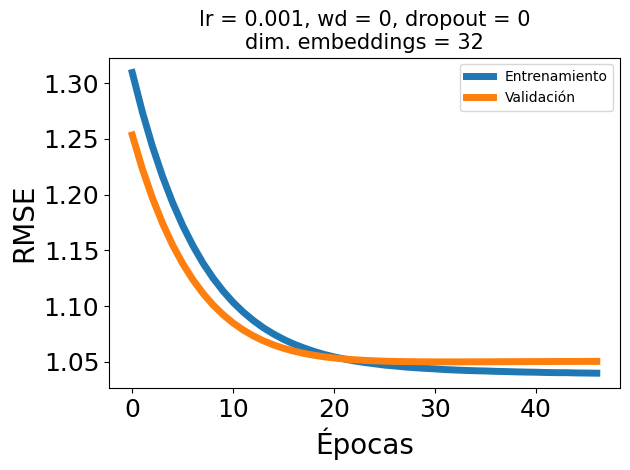

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.057 | Val Loss: 0.052
Epoch 10 |Train Loss: 0.049 | Val Loss: 0.047
Epoch 15 |Train Loss: 0.046 | Val Loss: 0.045
Epoch 20 |Train Loss: 0.045 | Val Loss: 0.045
Epoch 25 |Train Loss: 0.045 | Val Loss: 0.045
Epoch 30 |Train Loss: 0.045 | Val Loss: 0.045
Epoch 35 |Train Loss: 0.045 | Val Loss: 0.045
Epoch 40 |Train Loss: 0.044 | Val Loss: 0.045
Epoch 45 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 65 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 70 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 75 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 80 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 85 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 90 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 95 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 100 |Train Loss: 0.044 | V

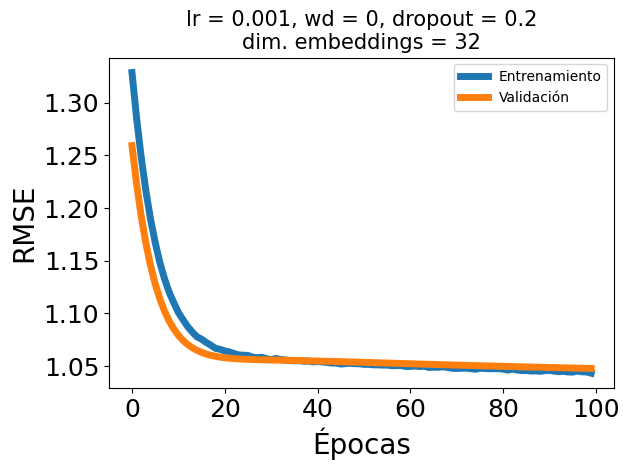

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.070 | Val Loss: 0.064
Epoch 10 |Train Loss: 0.055 | Val Loss: 0.052
Epoch 15 |Train Loss: 0.049 | Val Loss: 0.047
Epoch 20 |Train Loss: 0.047 | Val Loss: 0.045
Epoch 25 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 65 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 70 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 75 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 80 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 85 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 90 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 95 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 100 |Train Loss: 0.044 | V

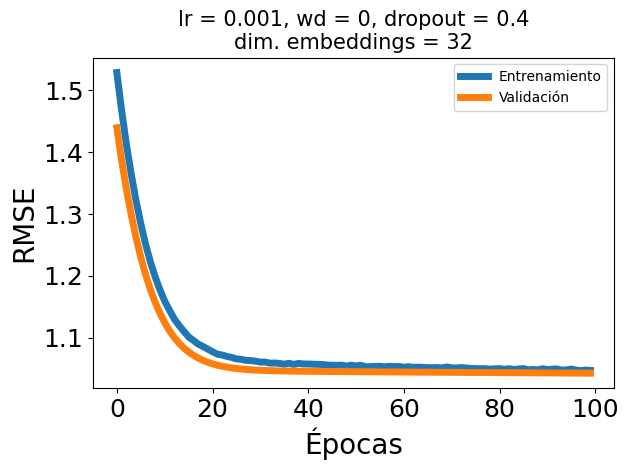

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.062 | Val Loss: 0.057
Epoch 10 |Train Loss: 0.051 | Val Loss: 0.048
Epoch 15 |Train Loss: 0.046 | Val Loss: 0.045
Epoch 20 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 70 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 80 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 85 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.043 | 

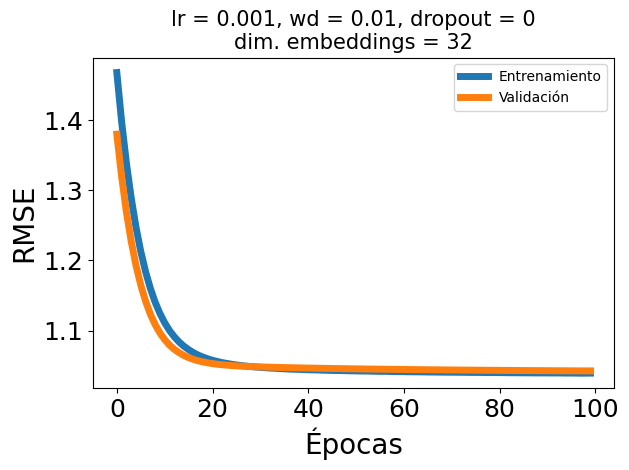

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.065 | Val Loss: 0.060
Epoch 10 |Train Loss: 0.055 | Val Loss: 0.051
Epoch 15 |Train Loss: 0.049 | Val Loss: 0.047
Epoch 20 |Train Loss: 0.047 | Val Loss: 0.046
Epoch 25 |Train Loss: 0.046 | Val Loss: 0.045
Epoch 30 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 65 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 70 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 75 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 80 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 85 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 100 |Train Loss: 0.043 

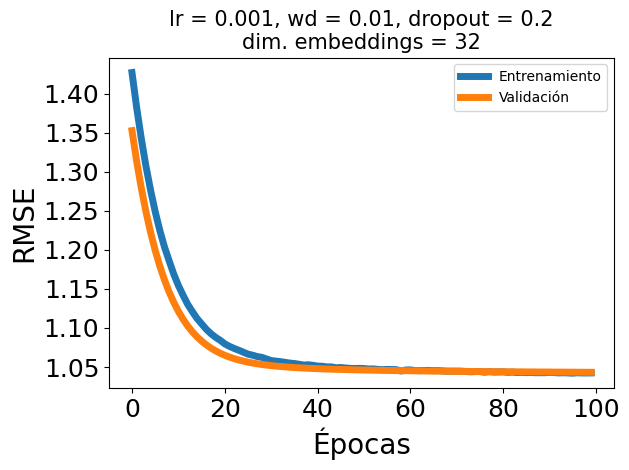

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.065 | Val Loss: 0.058
Epoch 10 |Train Loss: 0.053 | Val Loss: 0.049
Epoch 15 |Train Loss: 0.049 | Val Loss: 0.046
Epoch 20 |Train Loss: 0.047 | Val Loss: 0.045
Epoch 25 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 65 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 70 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 75 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 80 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 85 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 90 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 95 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 100 |Train Loss: 0.044 

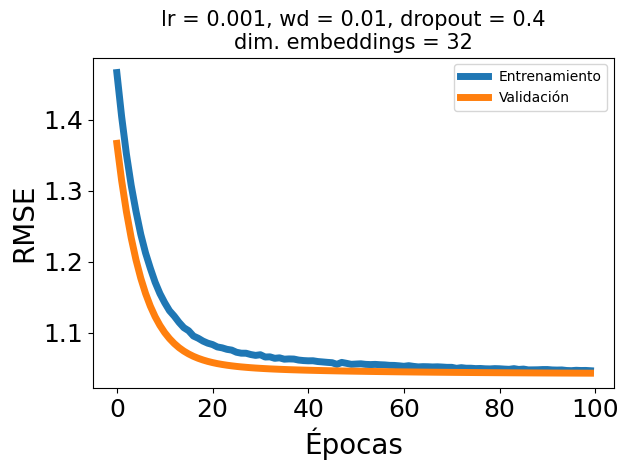

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.067 | Val Loss: 0.061
Epoch 10 |Train Loss: 0.053 | Val Loss: 0.049
Epoch 15 |Train Loss: 0.047 | Val Loss: 0.045
Epoch 20 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 42


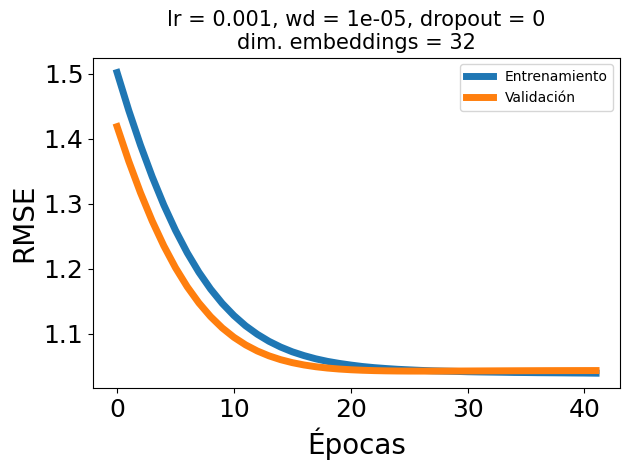

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.079 | Val Loss: 0.071
Epoch 10 |Train Loss: 0.059 | Val Loss: 0.055
Epoch 15 |Train Loss: 0.050 | Val Loss: 0.048
Epoch 20 |Train Loss: 0.047 | Val Loss: 0.045
Epoch 25 |Train Loss: 0.045 | Val Loss: 0.045
Epoch 30 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 65 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 70 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 75 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 80 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 85 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 90 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 100 |Train Loss: 0.043

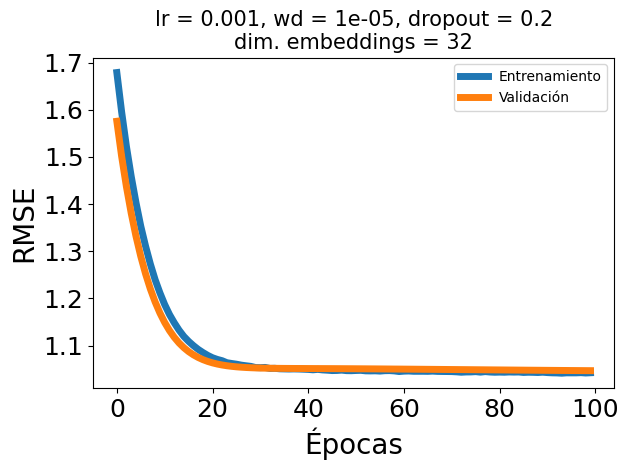

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.068 | Val Loss: 0.061
Epoch 10 |Train Loss: 0.054 | Val Loss: 0.051
Epoch 15 |Train Loss: 0.049 | Val Loss: 0.047
Epoch 20 |Train Loss: 0.047 | Val Loss: 0.045
Epoch 25 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 65 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 70 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 75 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 80 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 85 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 90 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 95 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 100 |Train Loss: 0.044

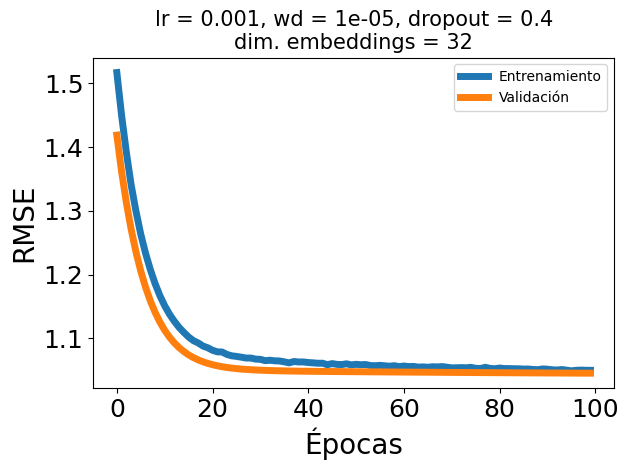

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.045
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 95 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 100 |Train Loss: 0.041 | Val

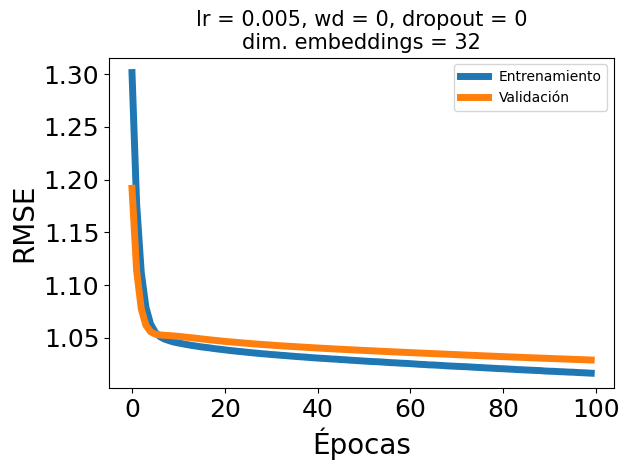

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 75 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 80 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 100 |Train Loss: 0.042 | V

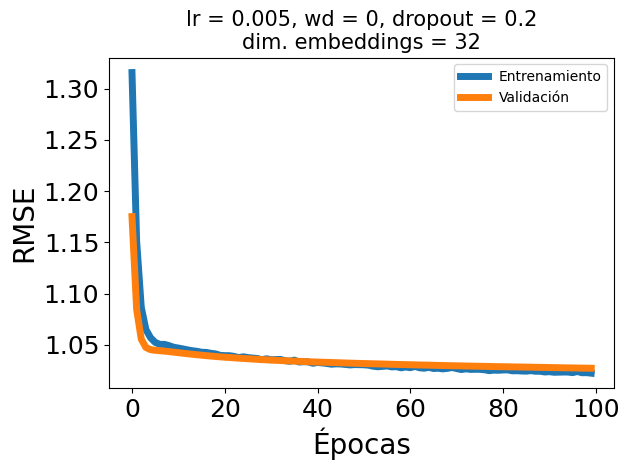

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.043
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.043 | V

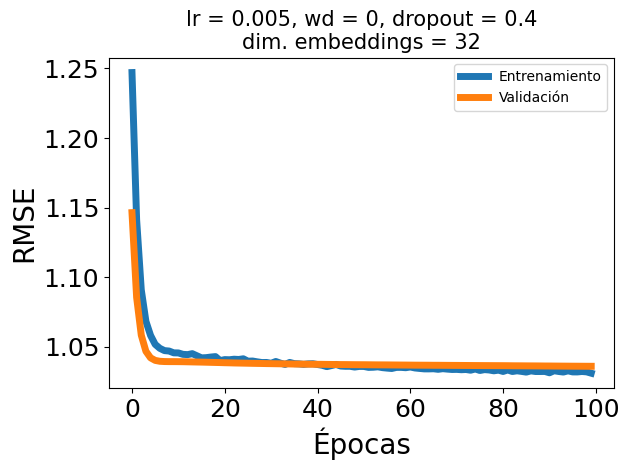

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 51


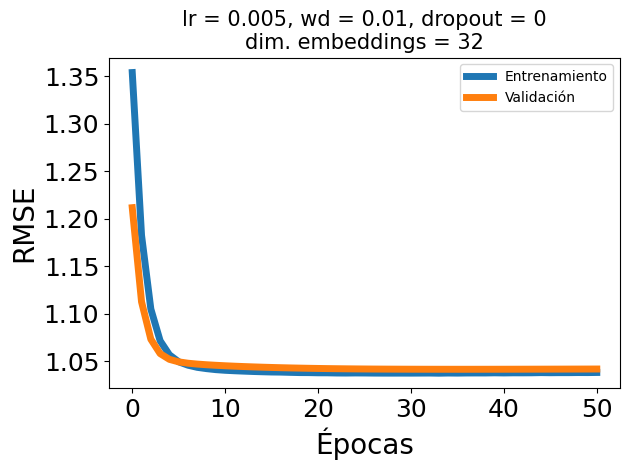

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 44


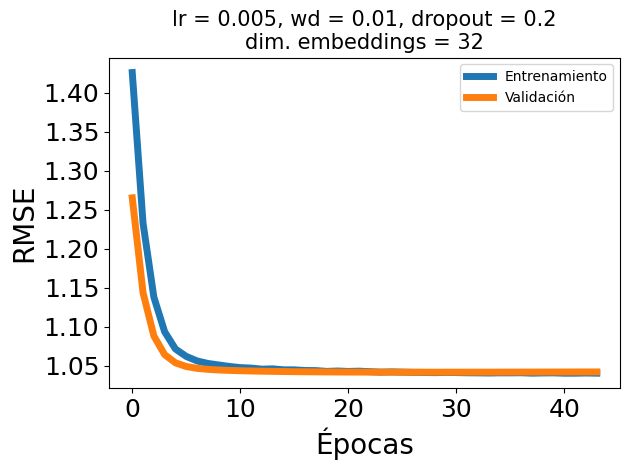

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.047 | Val Loss: 0.045
Epoch 10 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 53


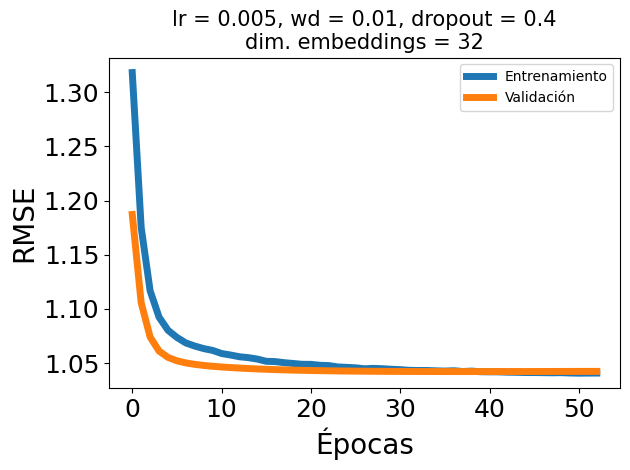

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 100 |Train Loss: 0.042 |

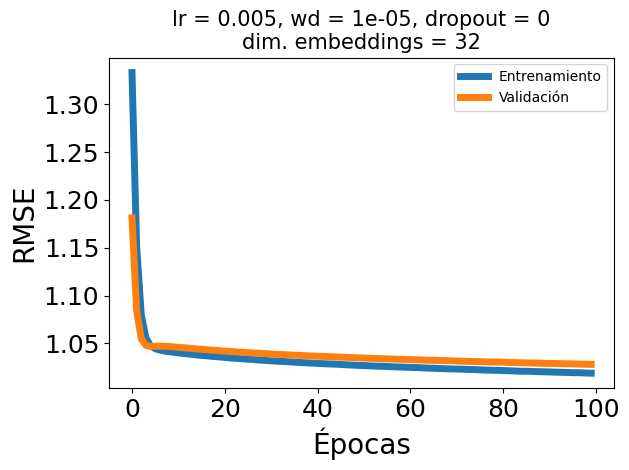

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.042

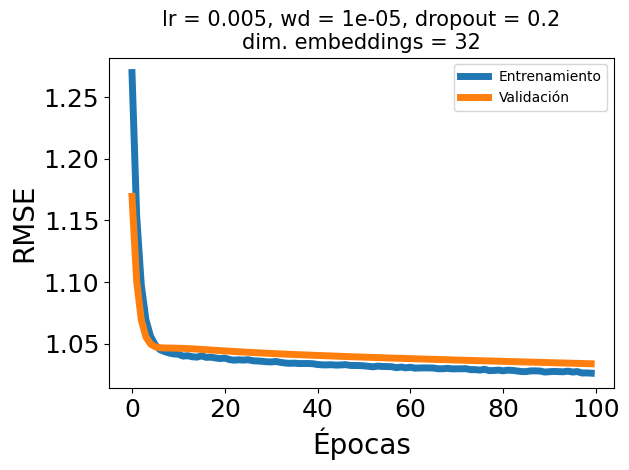

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.046 | Val Loss: 0.045
Epoch 10 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.043

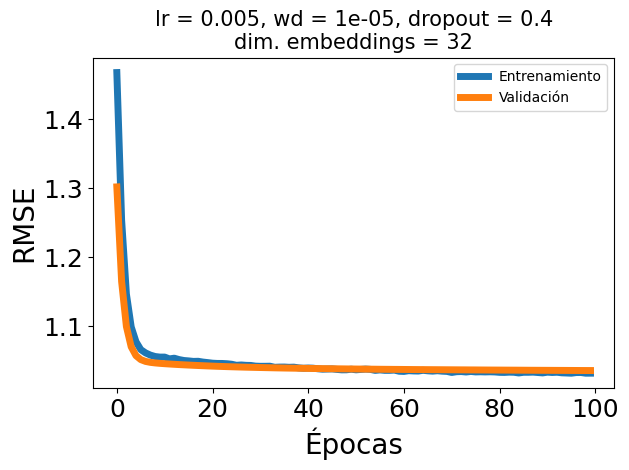

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.041 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.041 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.041 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.041 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.041 | Val 

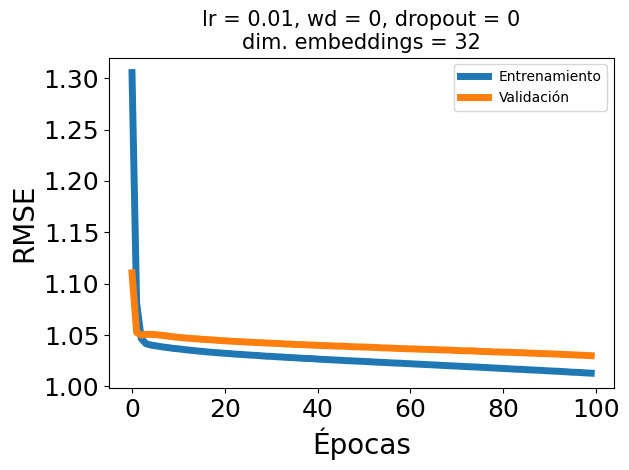

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 100 |Train Loss: 0.042 | Va

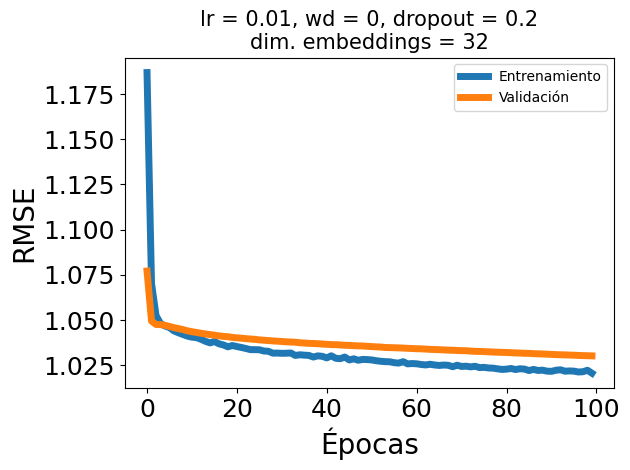

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.042 | Va

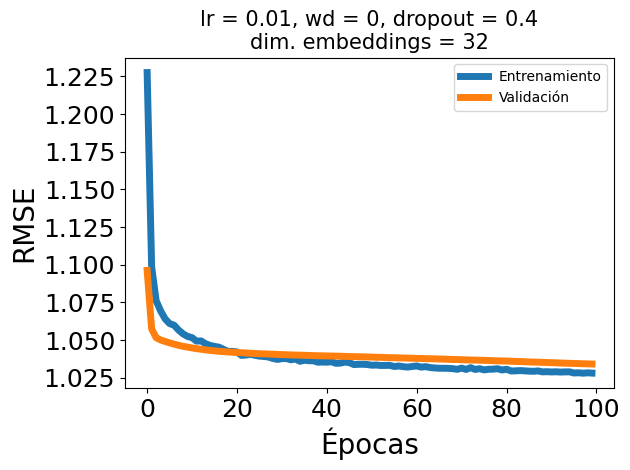

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 32


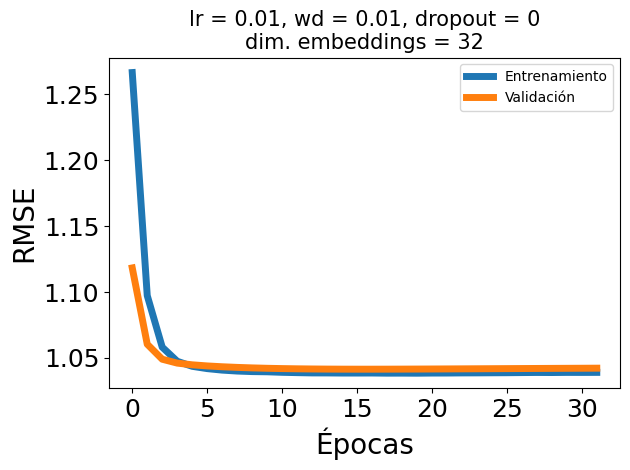

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 28


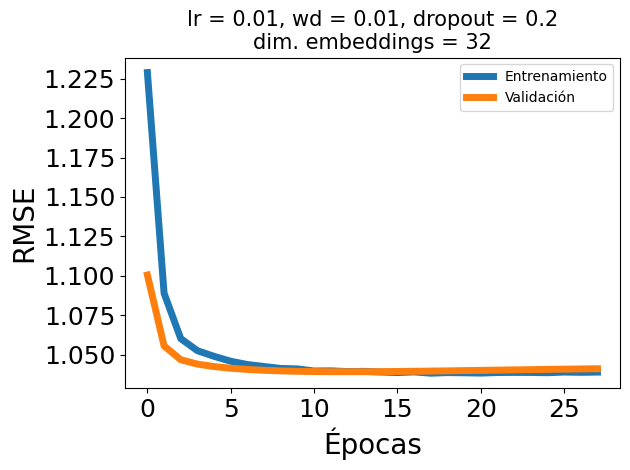

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 33


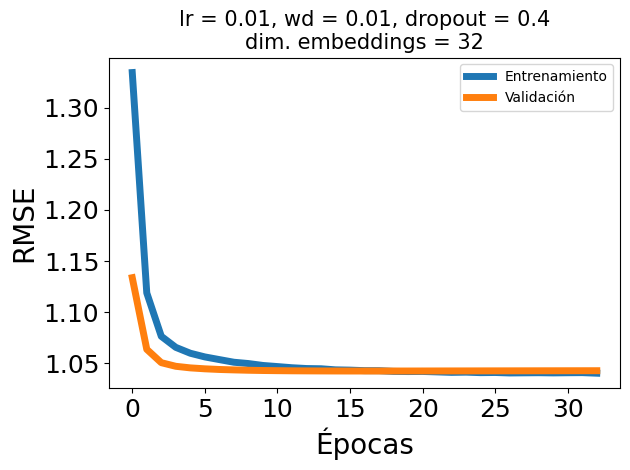

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 45 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 50 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 55 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 60 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 65 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 70 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 75 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 80 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 85 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 90 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 95 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 100 |Train Loss: 0.040 | 

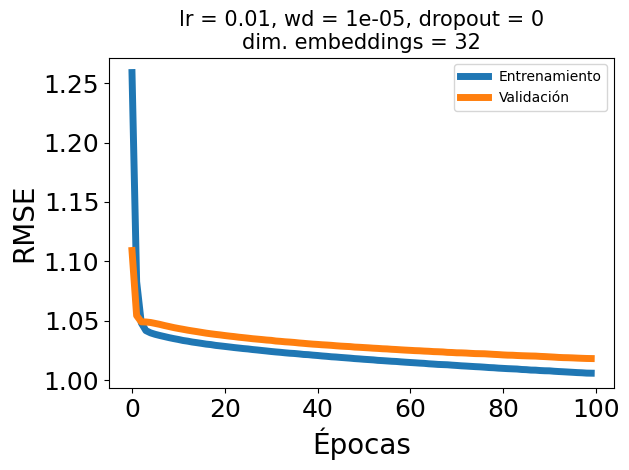

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.042 

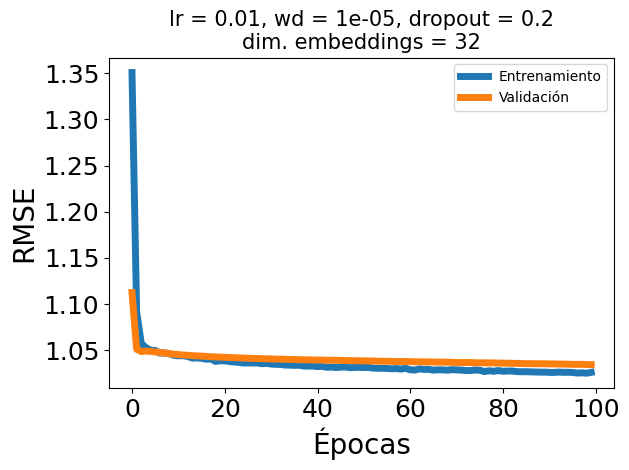

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=32
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.042 

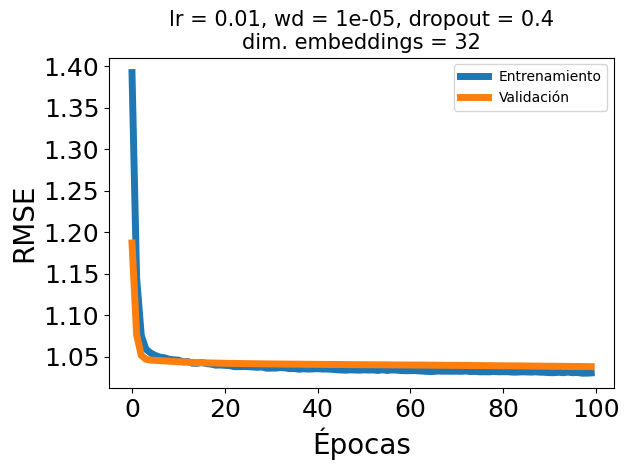

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.071 | Val Loss: 0.064
Epoch 10 |Train Loss: 0.053 | Val Loss: 0.050
Epoch 15 |Train Loss: 0.047 | Val Loss: 0.045
Epoch 20 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.042 | Val

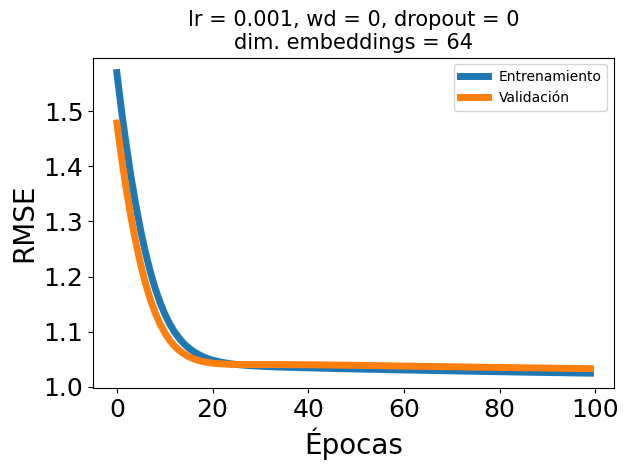

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.066 | Val Loss: 0.060
Epoch 10 |Train Loss: 0.053 | Val Loss: 0.050
Epoch 15 |Train Loss: 0.048 | Val Loss: 0.046
Epoch 20 |Train Loss: 0.046 | Val Loss: 0.045
Epoch 25 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 70 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.043 | V

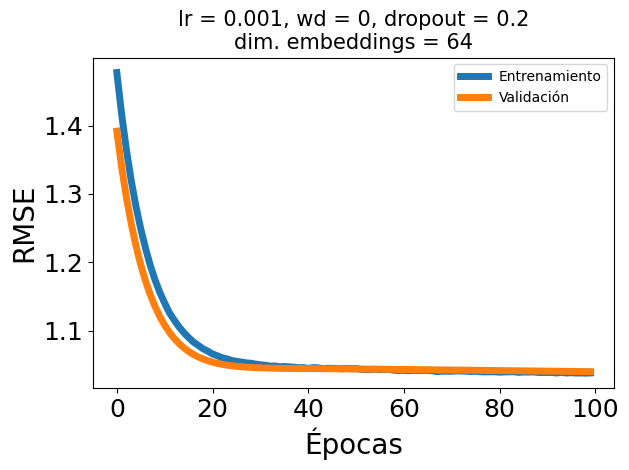

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.061 | Val Loss: 0.057
Epoch 10 |Train Loss: 0.051 | Val Loss: 0.049
Epoch 15 |Train Loss: 0.048 | Val Loss: 0.046
Epoch 20 |Train Loss: 0.046 | Val Loss: 0.045
Epoch 25 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.044 | V

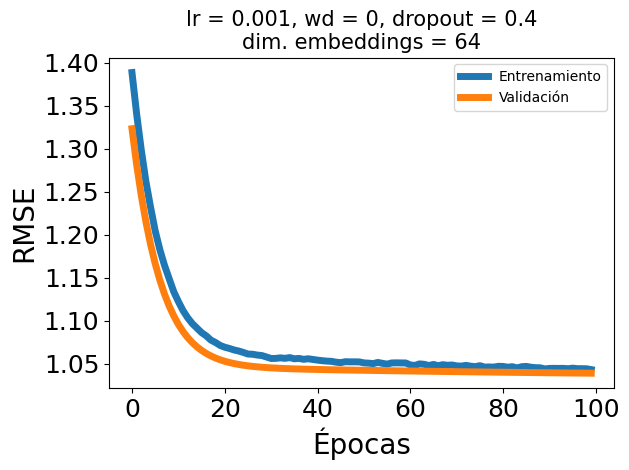

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.053 | Val Loss: 0.050
Epoch 10 |Train Loss: 0.047 | Val Loss: 0.045
Epoch 15 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.043 | 

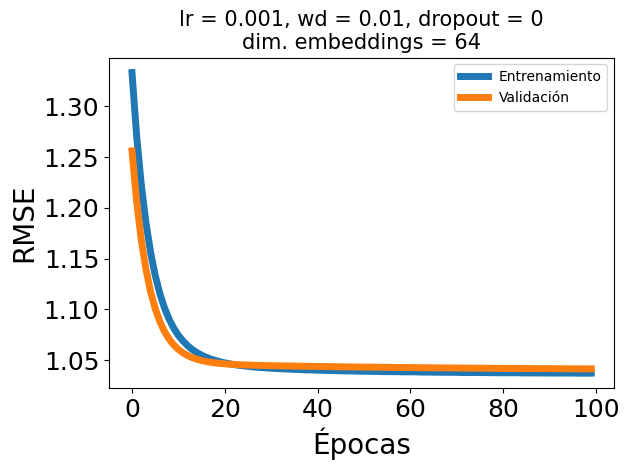

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.058 | Val Loss: 0.054
Epoch 10 |Train Loss: 0.051 | Val Loss: 0.048
Epoch 15 |Train Loss: 0.047 | Val Loss: 0.046
Epoch 20 |Train Loss: 0.046 | Val Loss: 0.045
Epoch 25 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.043 

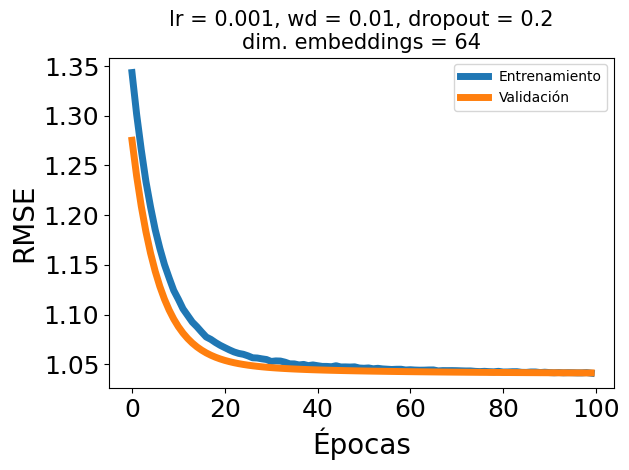

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.057 | Val Loss: 0.053
Epoch 10 |Train Loss: 0.051 | Val Loss: 0.048
Epoch 15 |Train Loss: 0.048 | Val Loss: 0.046
Epoch 20 |Train Loss: 0.046 | Val Loss: 0.045
Epoch 25 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 65 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 70 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 75 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 80 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 85 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.043 

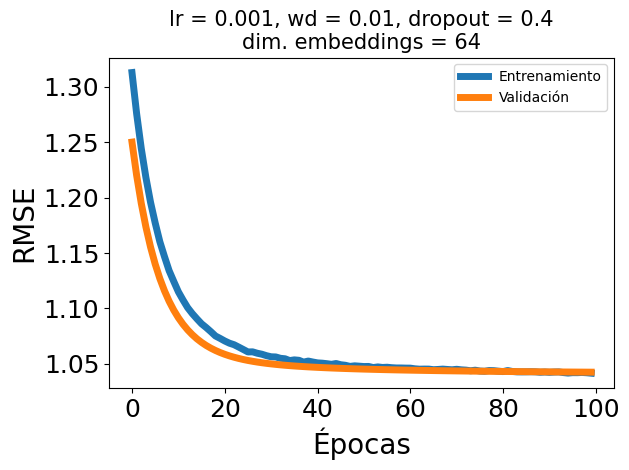

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.055 | Val Loss: 0.051
Epoch 10 |Train Loss: 0.048 | Val Loss: 0.046
Epoch 15 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.044
Early stopping en la época: 42


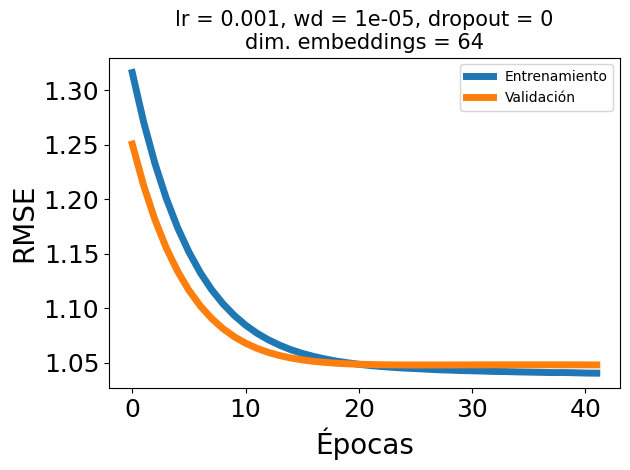

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.066 | Val Loss: 0.061
Epoch 10 |Train Loss: 0.053 | Val Loss: 0.050
Epoch 15 |Train Loss: 0.048 | Val Loss: 0.046
Epoch 20 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 70 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.043

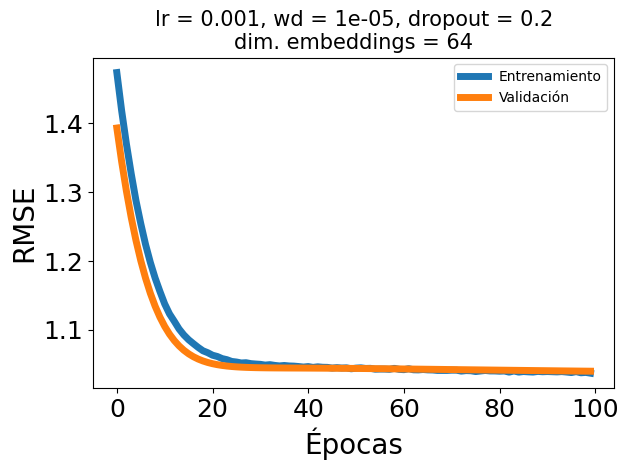

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.077 | Val Loss: 0.069
Epoch 10 |Train Loss: 0.060 | Val Loss: 0.056
Epoch 15 |Train Loss: 0.052 | Val Loss: 0.049
Epoch 20 |Train Loss: 0.048 | Val Loss: 0.046
Epoch 25 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.045 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.045 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.044

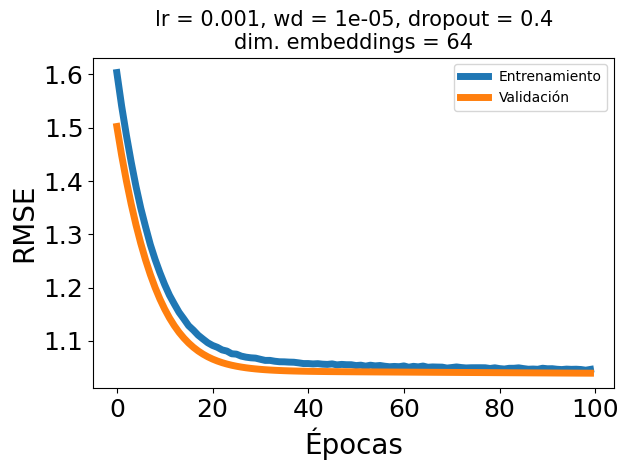

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.041 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.041 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 65 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 70 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 75 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 80 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 85 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 90 |Train Loss: 0.040 | Val Loss: 0.042
Epoch 95 |Train Loss: 0.040 | Val Loss: 0.042
Epoch 100 |Train Loss: 0.040 | Val

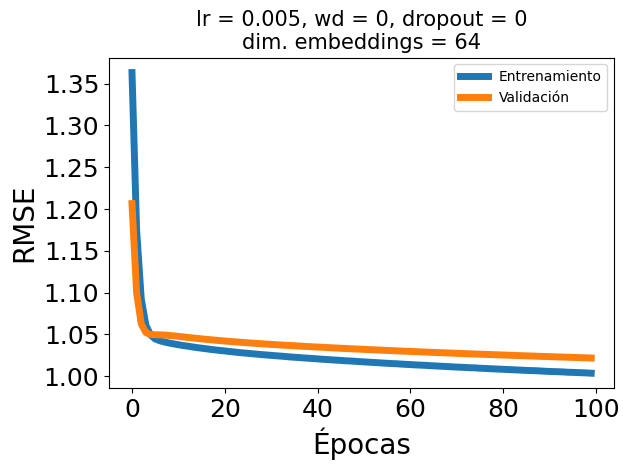

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 75 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 80 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 100 |Train Loss: 0.042 | V

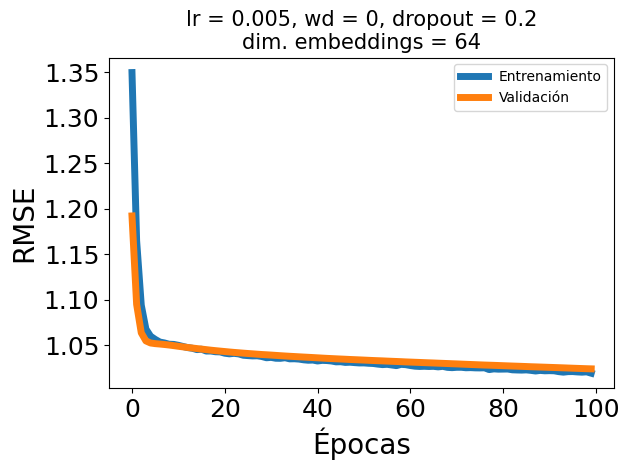

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.043 | V

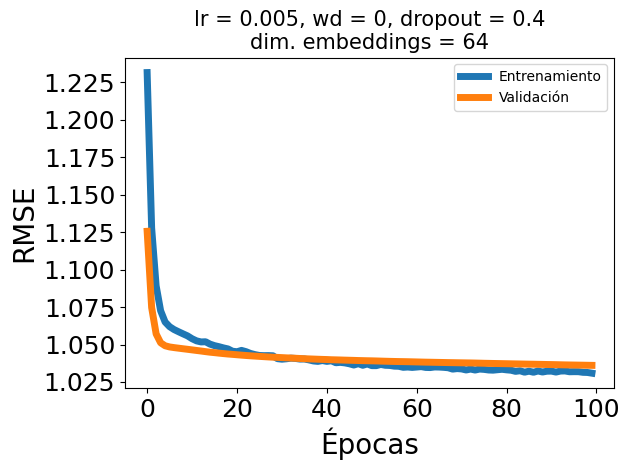

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 39


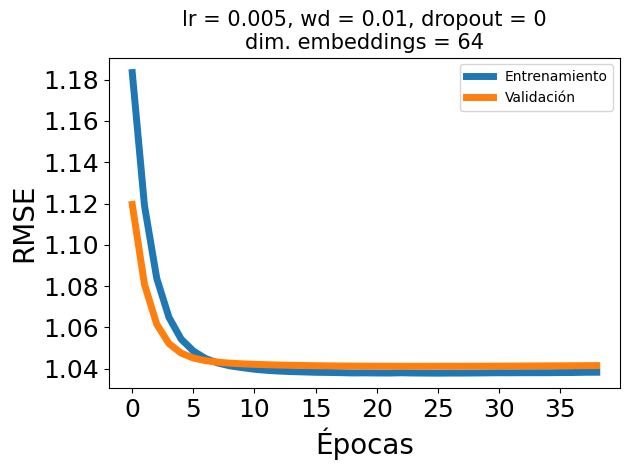

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 49


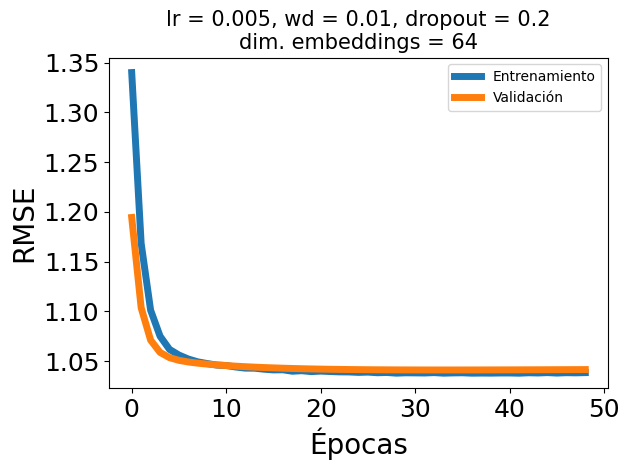

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 34


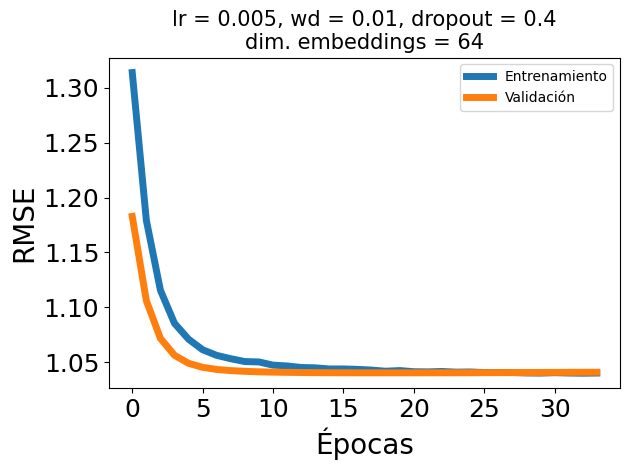

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 70 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 75 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 80 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 85 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 90 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 95 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 100 |Train Loss: 0.041 |

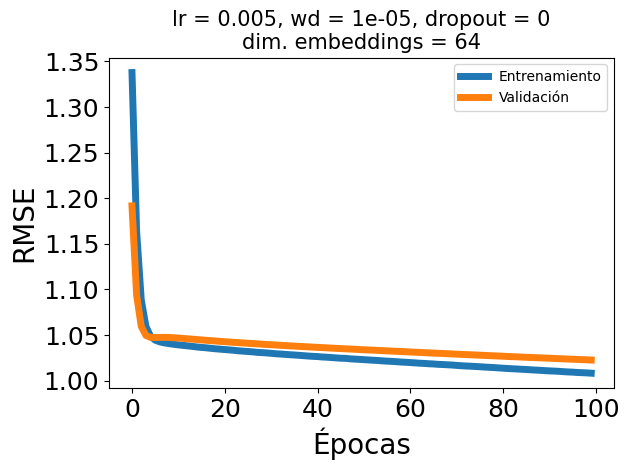

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.042

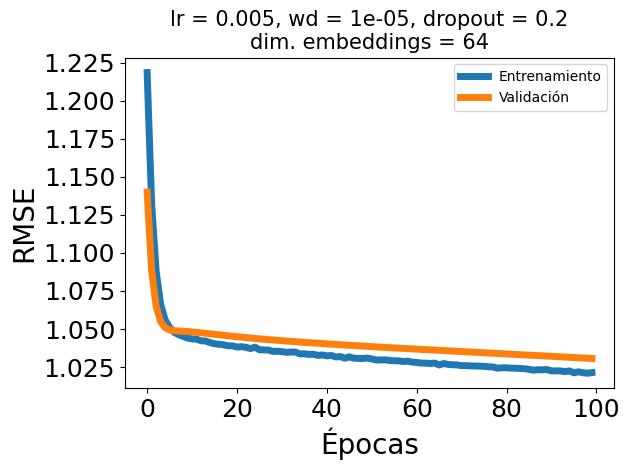

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.047 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.042

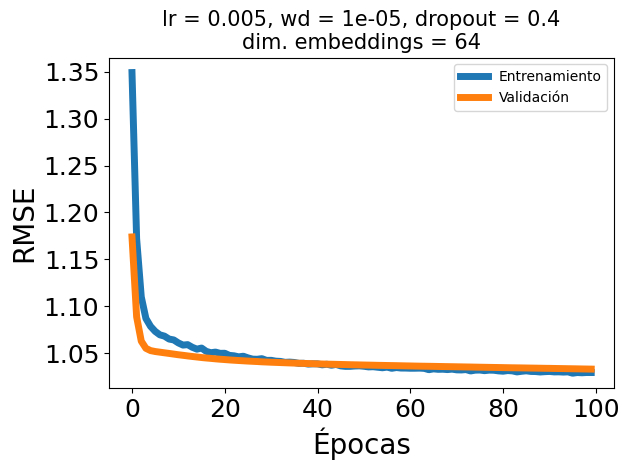

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 40 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 45 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 50 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 55 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 60 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 65 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 70 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 75 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 80 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 85 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 90 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 95 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 100 |Train Loss: 0.039 | Val 

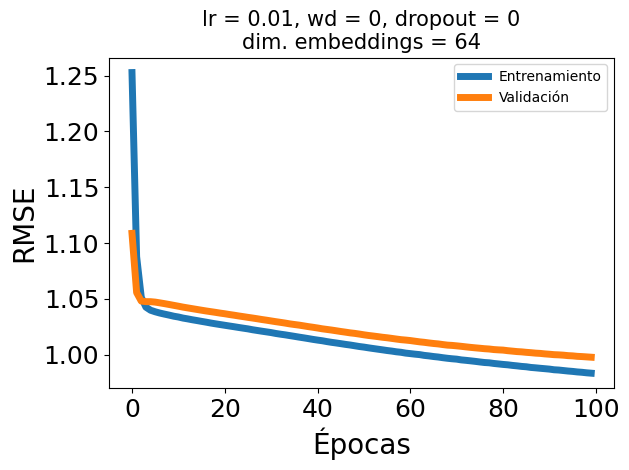

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 55 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 70 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 75 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 80 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 85 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 90 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 95 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 100 |Train Loss: 0.041 | Va

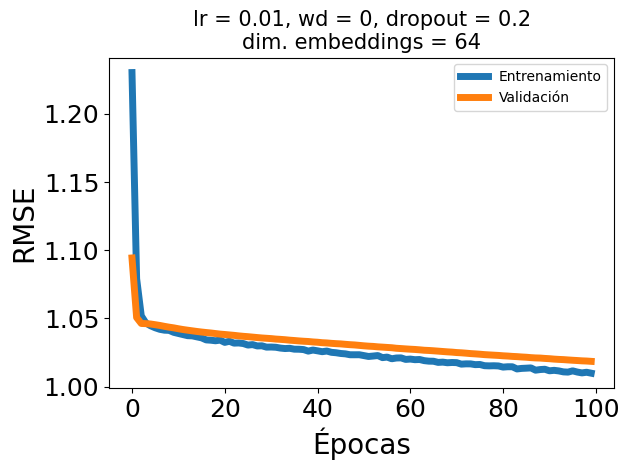

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 75 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 80 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 100 |Train Loss: 0.042 | Va

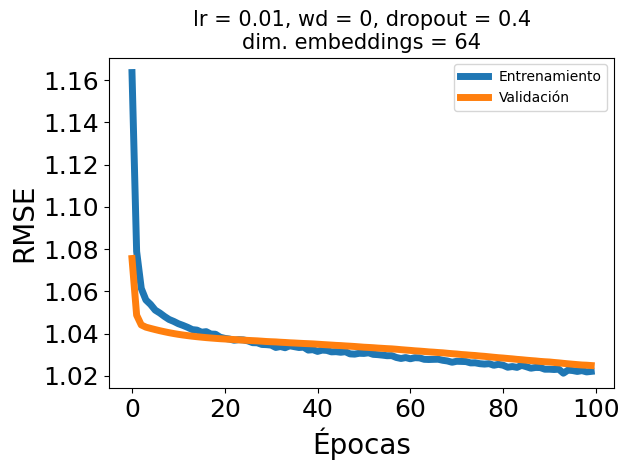

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 31


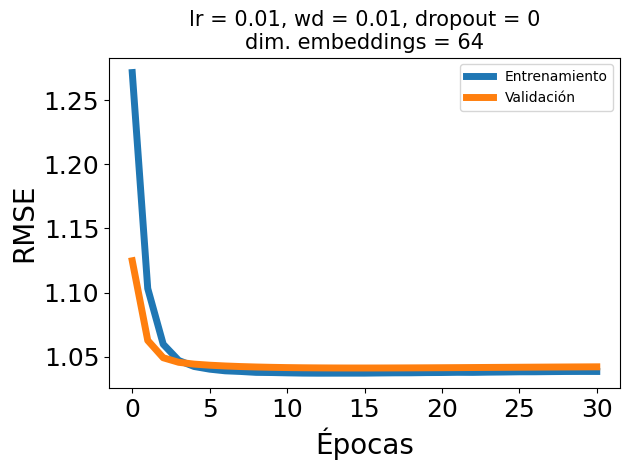

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 34


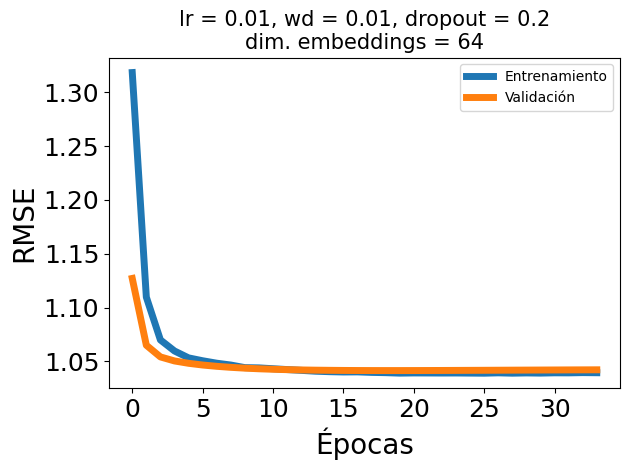

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 31


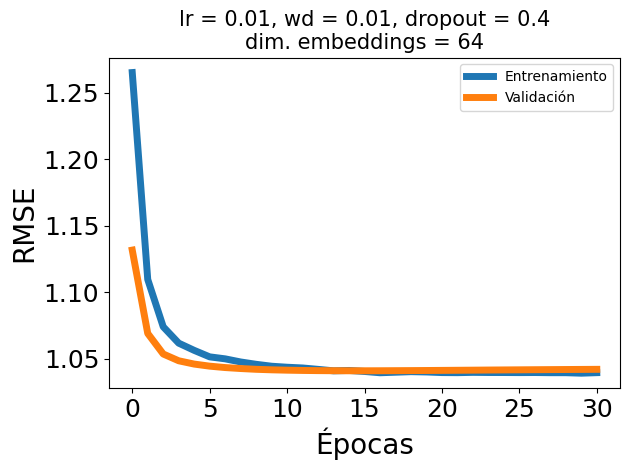

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 35 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 40 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 45 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 50 |Train Loss: 0.040 | Val Loss: 0.042
Epoch 55 |Train Loss: 0.040 | Val Loss: 0.042
Epoch 60 |Train Loss: 0.040 | Val Loss: 0.042
Epoch 65 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 70 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 75 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 80 |Train Loss: 0.039 | Val Loss: 0.041
Epoch 85 |Train Loss: 0.039 | Val Loss: 0.041
Epoch 90 |Train Loss: 0.039 | Val Loss: 0.041
Epoch 95 |Train Loss: 0.039 | Val Loss: 0.041
Epoch 100 |Train Loss: 0.039 | 

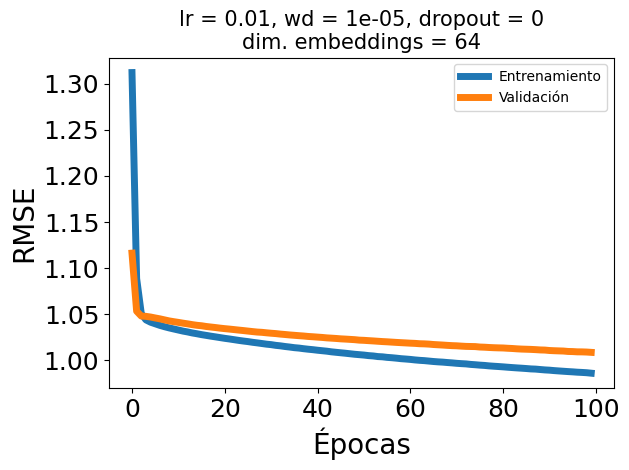

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 40 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 45 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 50 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 55 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 60 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 65 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 70 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 75 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 80 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 85 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 90 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 95 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 100 |Train Loss: 0.040 

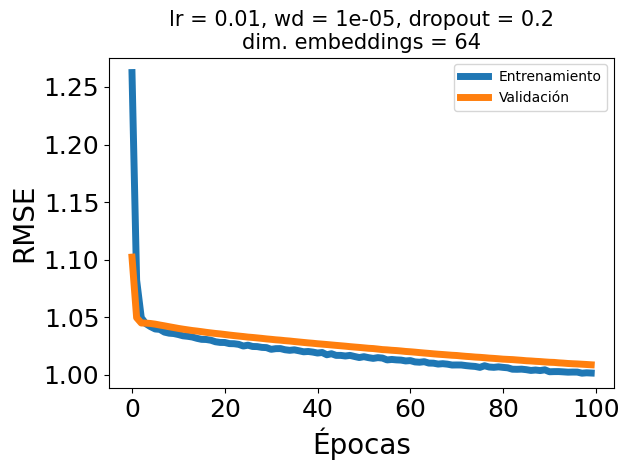

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=64
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.042 

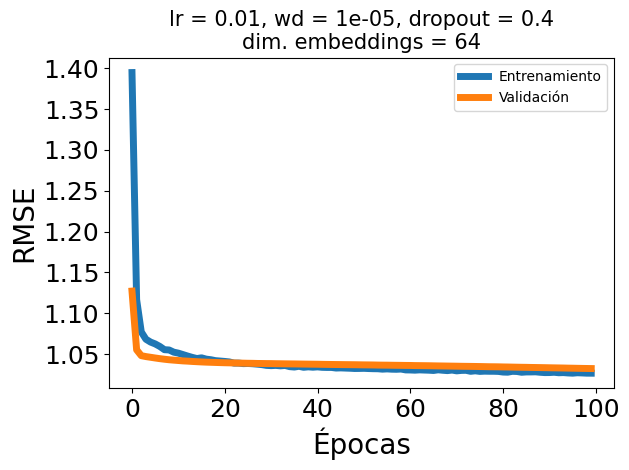

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.058 | Val Loss: 0.053
Epoch 10 |Train Loss: 0.049 | Val Loss: 0.047
Epoch 15 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 20 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.042 | Val

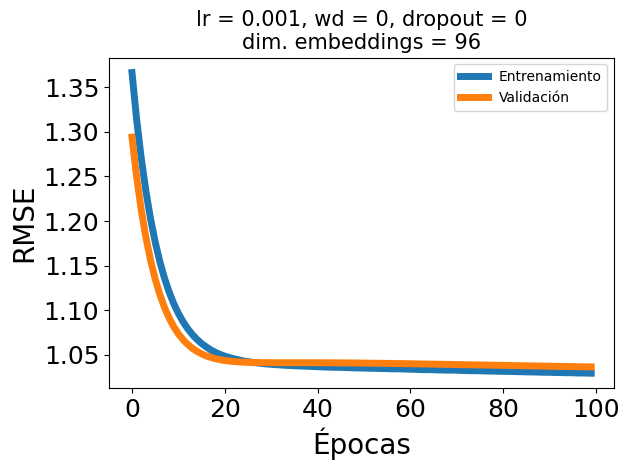

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.057 | Val Loss: 0.053
Epoch 10 |Train Loss: 0.049 | Val Loss: 0.047
Epoch 15 |Train Loss: 0.046 | Val Loss: 0.045
Epoch 20 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.043 | V

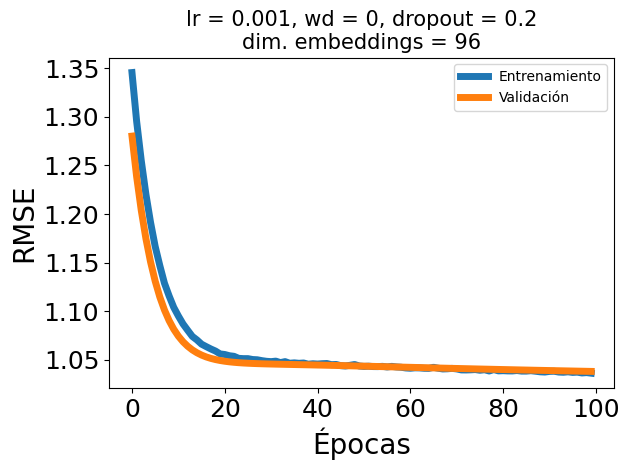

Entrenamiento con parámetros: lr=0.001, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.056 | Val Loss: 0.052
Epoch 10 |Train Loss: 0.049 | Val Loss: 0.047
Epoch 15 |Train Loss: 0.047 | Val Loss: 0.045
Epoch 20 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.044 | V

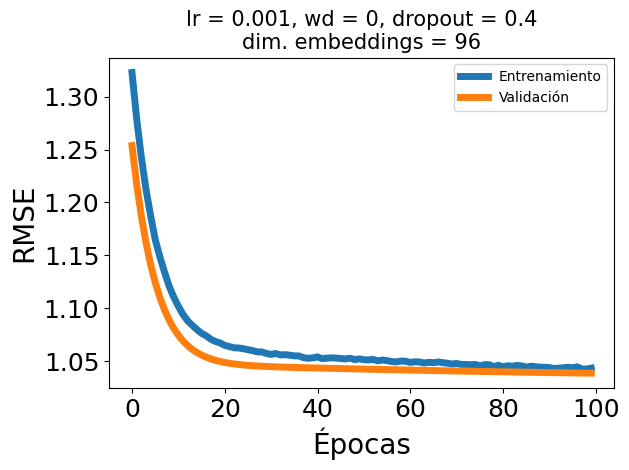

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.067 | Val Loss: 0.061
Epoch 10 |Train Loss: 0.054 | Val Loss: 0.051
Epoch 15 |Train Loss: 0.049 | Val Loss: 0.047
Epoch 20 |Train Loss: 0.046 | Val Loss: 0.045
Epoch 25 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.043 | 

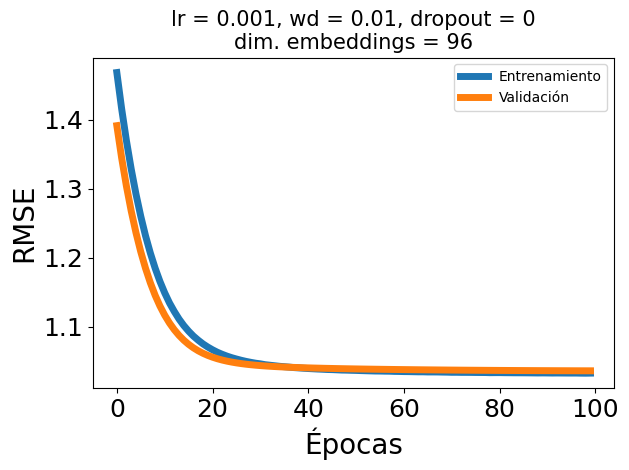

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.064 | Val Loss: 0.059
Epoch 10 |Train Loss: 0.053 | Val Loss: 0.050
Epoch 15 |Train Loss: 0.048 | Val Loss: 0.046
Epoch 20 |Train Loss: 0.046 | Val Loss: 0.045
Epoch 25 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.043 

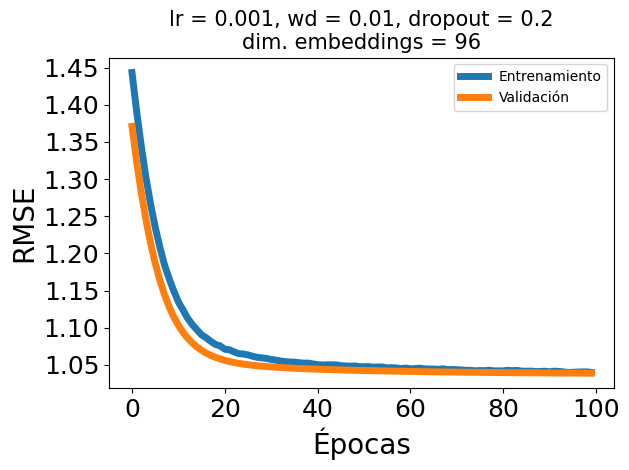

Entrenamiento con parámetros: lr=0.001, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.055 | Val Loss: 0.051
Epoch 10 |Train Loss: 0.050 | Val Loss: 0.047
Epoch 15 |Train Loss: 0.047 | Val Loss: 0.045
Epoch 20 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.043 

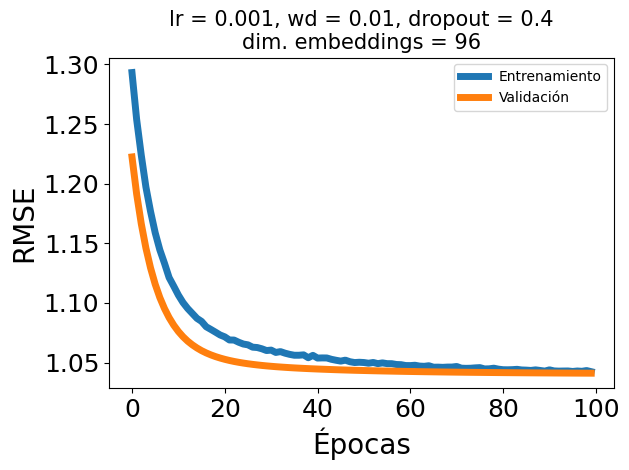

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.073 | Val Loss: 0.066
Epoch 10 |Train Loss: 0.055 | Val Loss: 0.052
Epoch 15 |Train Loss: 0.048 | Val Loss: 0.046
Epoch 20 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 70 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.042 |

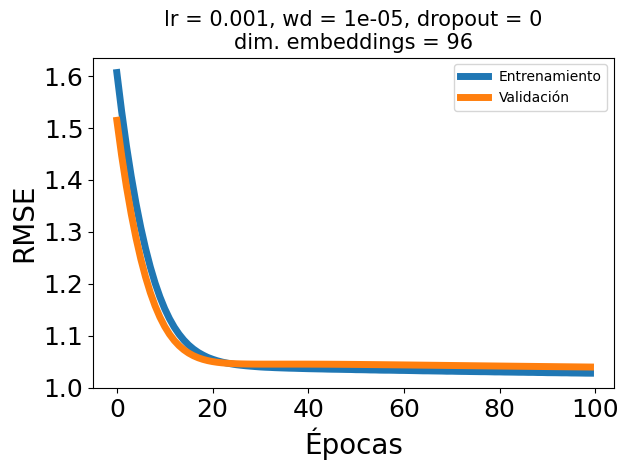

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.063 | Val Loss: 0.058
Epoch 10 |Train Loss: 0.052 | Val Loss: 0.049
Epoch 15 |Train Loss: 0.047 | Val Loss: 0.045
Epoch 20 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 60 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.043

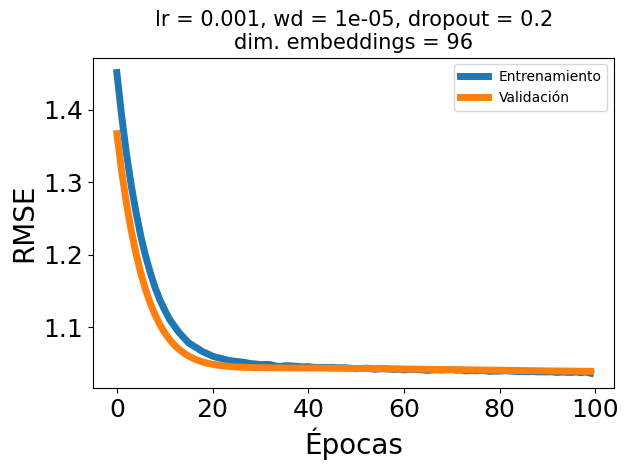

Entrenamiento con parámetros: lr=0.001, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.063 | Val Loss: 0.057
Epoch 10 |Train Loss: 0.052 | Val Loss: 0.049
Epoch 15 |Train Loss: 0.048 | Val Loss: 0.046
Epoch 20 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 25 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 30 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 35 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 40 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 45 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 50 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 95 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 100 |Train Loss: 0.044

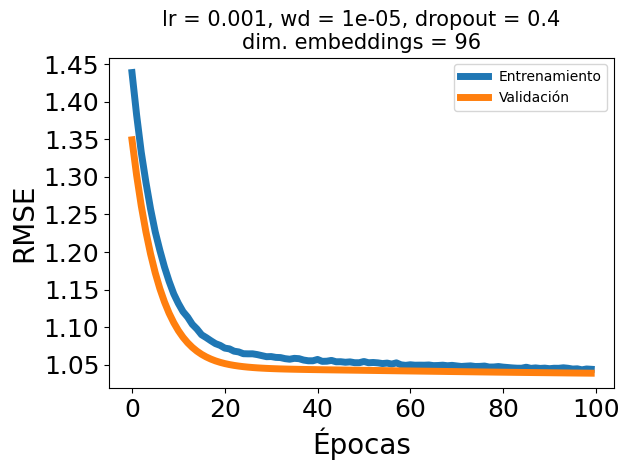

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 50 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 55 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 60 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 65 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 70 |Train Loss: 0.040 | Val Loss: 0.042
Epoch 75 |Train Loss: 0.040 | Val Loss: 0.042
Epoch 80 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 85 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 90 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 95 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 100 |Train Loss: 0.039 | Val

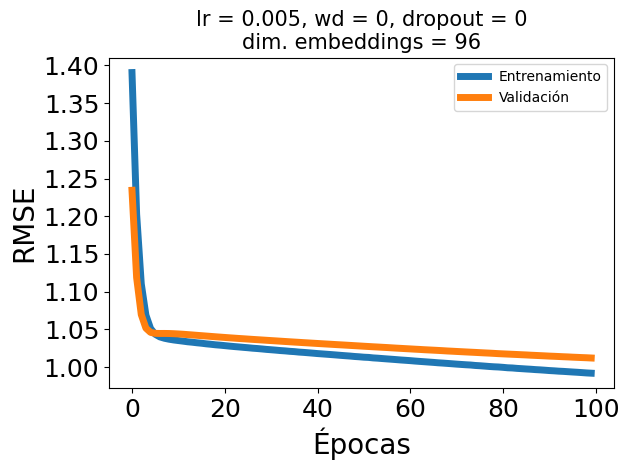

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 40 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 45 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 50 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 55 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 70 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 75 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 80 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 85 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 90 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 95 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 100 |Train Loss: 0.041 | V

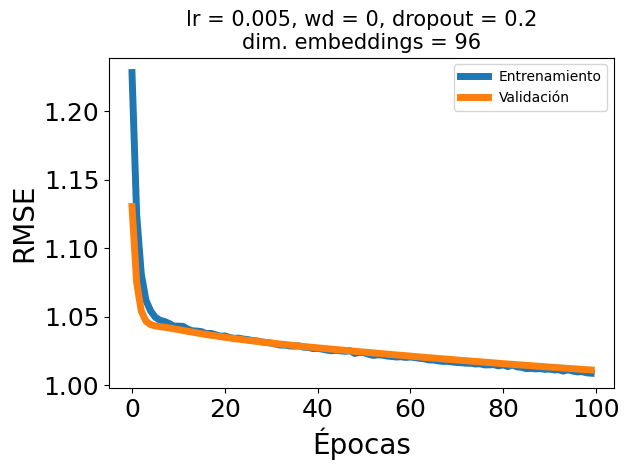

Entrenamiento con parámetros: lr=0.005, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.045 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.042
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.042
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.042
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.042
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.042
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 75 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 80 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 100 |Train Loss: 0.042 | V

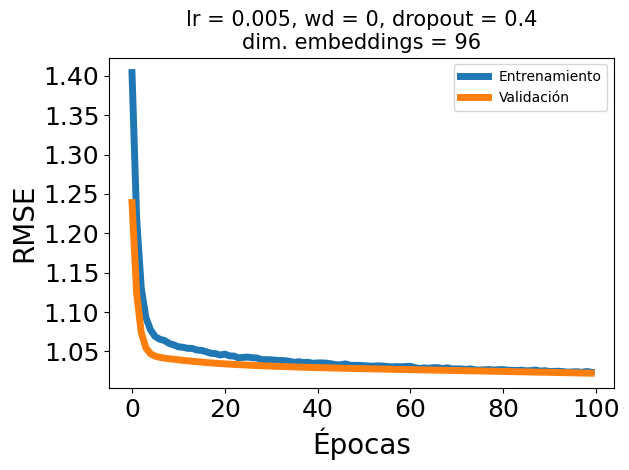

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 43


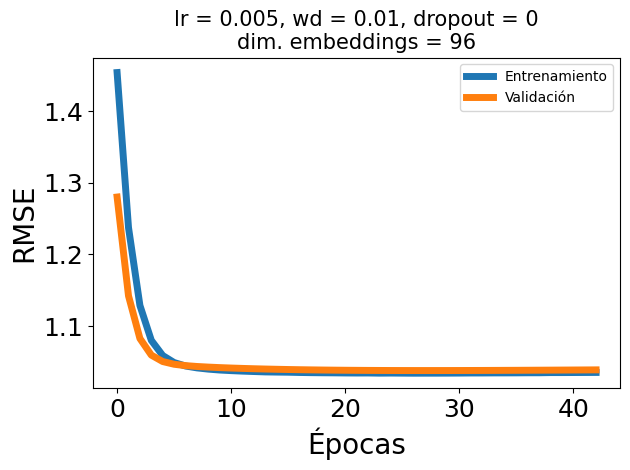

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 38


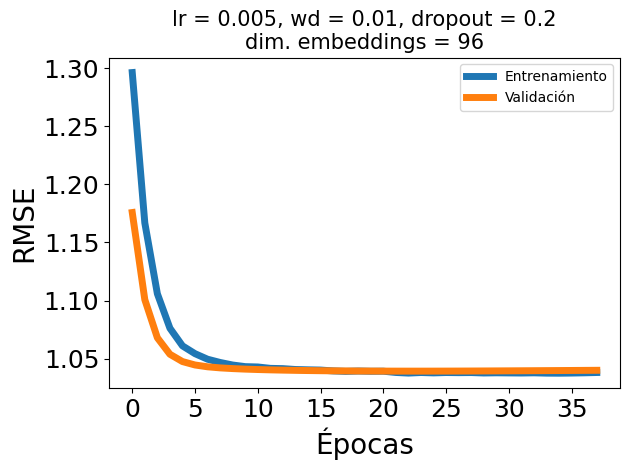

Entrenamiento con parámetros: lr=0.005, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 44


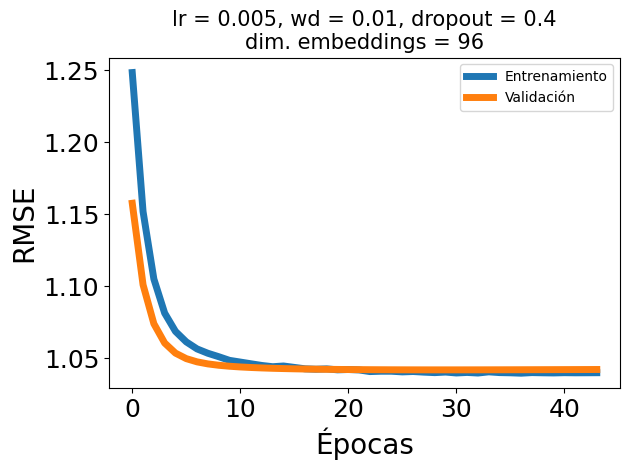

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 55 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 60 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 65 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 70 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 75 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 80 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 85 |Train Loss: 0.040 | Val Loss: 0.042
Epoch 90 |Train Loss: 0.040 | Val Loss: 0.042
Epoch 95 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 100 |Train Loss: 0.040 |

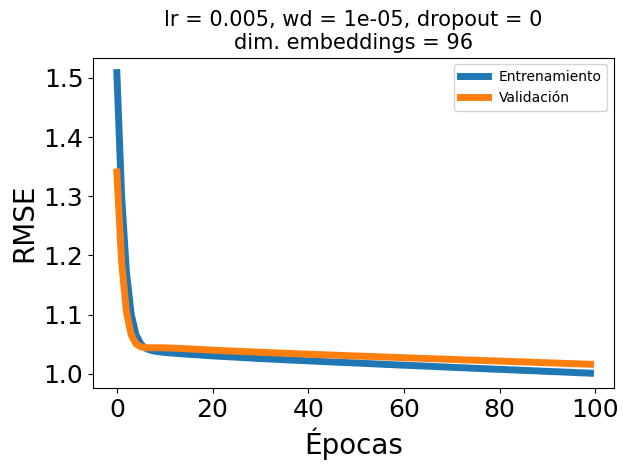

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 50 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 55 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 65 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 70 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 75 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 80 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 85 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 90 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 95 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 100 |Train Loss: 0.041

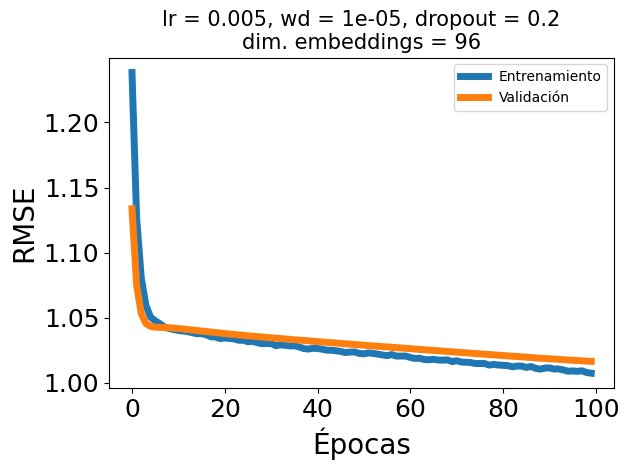

Entrenamiento con parámetros: lr=0.005, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.046 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 15 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 45 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 50 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 55 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 60 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 65 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 75 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 80 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 85 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 90 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 95 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 100 |Train Loss: 0.042

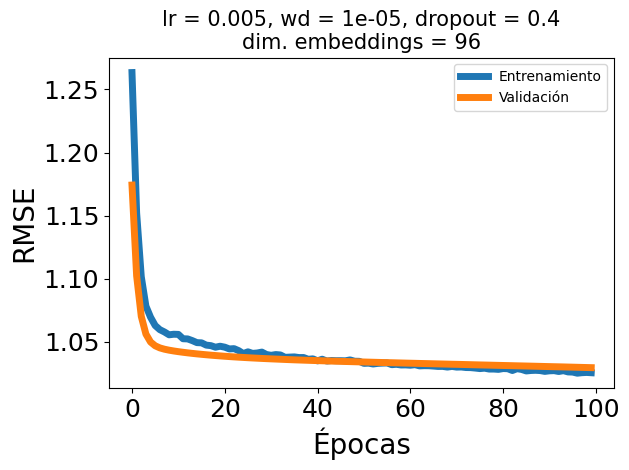

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 25 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 30 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 35 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 40 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 45 |Train Loss: 0.039 | Val Loss: 0.041
Epoch 50 |Train Loss: 0.039 | Val Loss: 0.041
Epoch 55 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 60 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 65 |Train Loss: 0.038 | Val Loss: 0.040
Epoch 70 |Train Loss: 0.038 | Val Loss: 0.040
Epoch 75 |Train Loss: 0.038 | Val Loss: 0.040
Epoch 80 |Train Loss: 0.038 | Val Loss: 0.040
Epoch 85 |Train Loss: 0.038 | Val Loss: 0.039
Epoch 90 |Train Loss: 0.037 | Val Loss: 0.039
Epoch 95 |Train Loss: 0.037 | Val Loss: 0.039
Epoch 100 |Train Loss: 0.037 | Val 

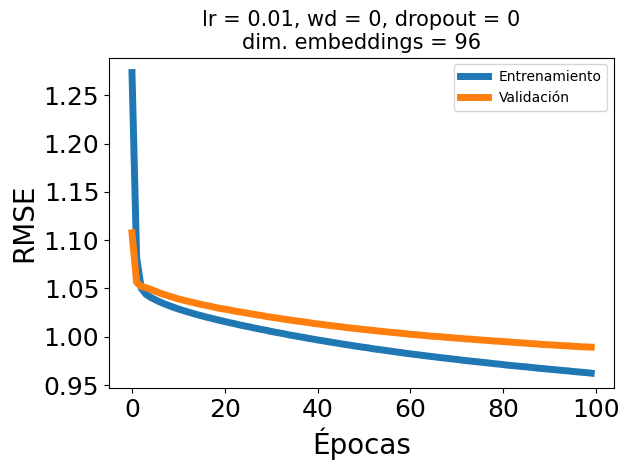

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0.2, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 25 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 30 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 35 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 40 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 45 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 50 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 55 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 60 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 65 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 70 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 75 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 80 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 85 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 90 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 95 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 100 |Train Loss: 0.039 | Va

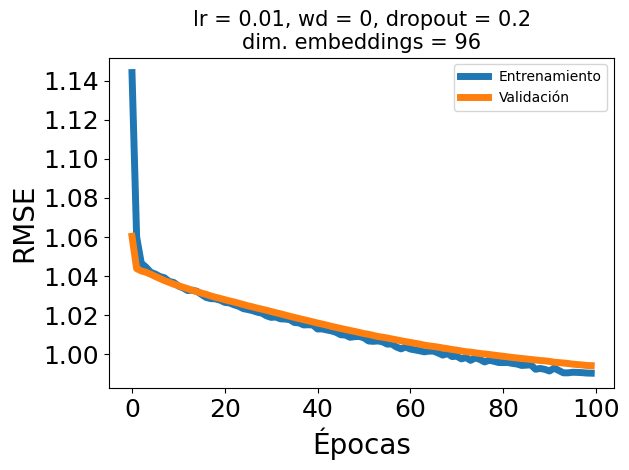

Entrenamiento con parámetros: lr=0.01, wd=0, drop=0.4, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 35 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 40 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 45 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 50 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 55 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 70 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 75 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 80 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 85 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 90 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 95 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 100 |Train Loss: 0.041 | Va

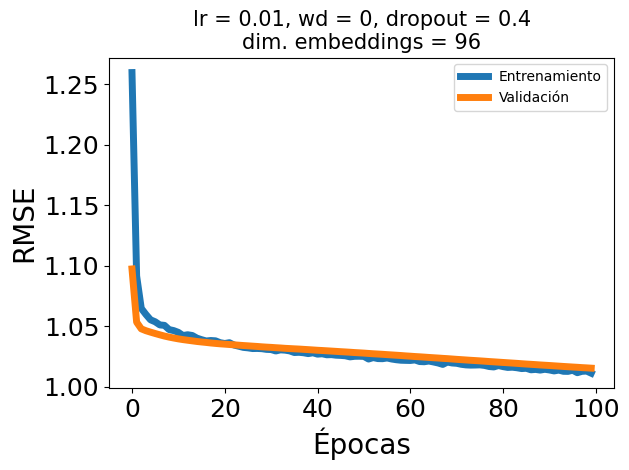

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 30


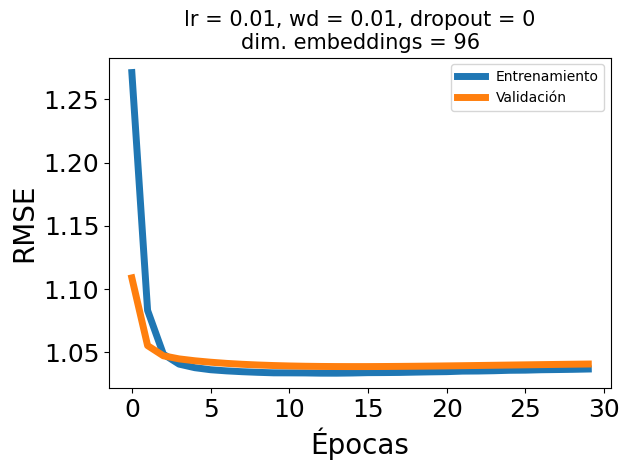

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0.2, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 26


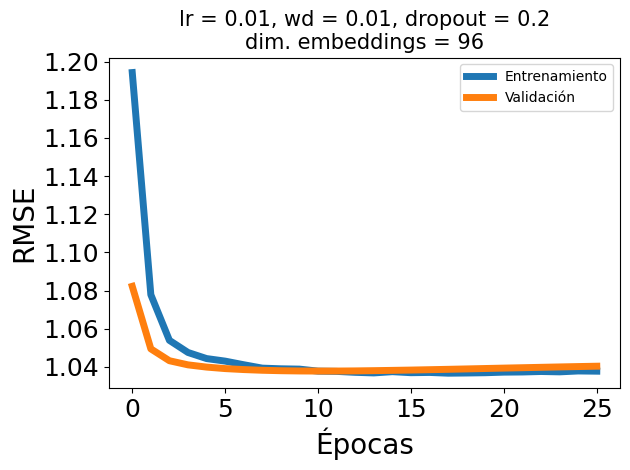

Entrenamiento con parámetros: lr=0.01, wd=0.01, drop=0.4, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 30 |Train Loss: 0.043 | Val Loss: 0.043
Early stopping en la época: 30


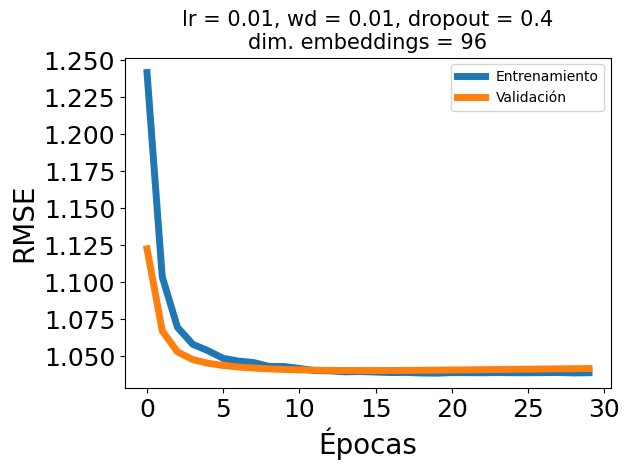

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.043 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.042 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 25 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 30 |Train Loss: 0.040 | Val Loss: 0.042
Epoch 35 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 40 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 45 |Train Loss: 0.039 | Val Loss: 0.041
Epoch 50 |Train Loss: 0.039 | Val Loss: 0.041
Epoch 55 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 60 |Train Loss: 0.039 | Val Loss: 0.040
Epoch 65 |Train Loss: 0.038 | Val Loss: 0.040
Epoch 70 |Train Loss: 0.038 | Val Loss: 0.040
Epoch 75 |Train Loss: 0.038 | Val Loss: 0.040
Epoch 80 |Train Loss: 0.038 | Val Loss: 0.040
Epoch 85 |Train Loss: 0.038 | Val Loss: 0.039
Epoch 90 |Train Loss: 0.037 | Val Loss: 0.039
Epoch 95 |Train Loss: 0.037 | Val Loss: 0.039
Epoch 100 |Train Loss: 0.037 | 

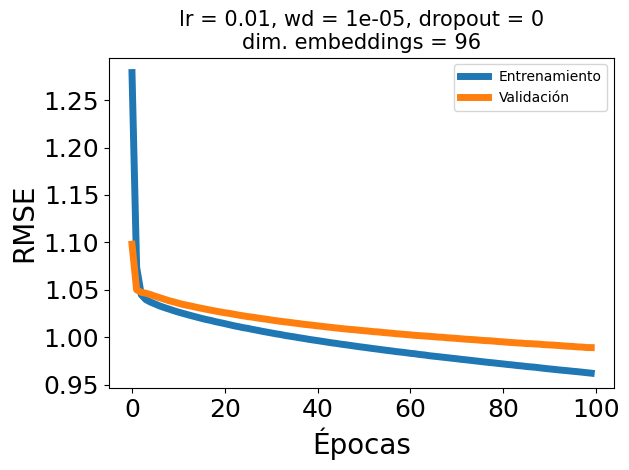

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0.2, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.044 | Val Loss: 0.044
Epoch 10 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 25 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 30 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 35 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 40 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 45 |Train Loss: 0.041 | Val Loss: 0.042
Epoch 50 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 55 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 60 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 65 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 70 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 75 |Train Loss: 0.040 | Val Loss: 0.041
Epoch 80 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 85 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 90 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 95 |Train Loss: 0.040 | Val Loss: 0.040
Epoch 100 |Train Loss: 0.040 

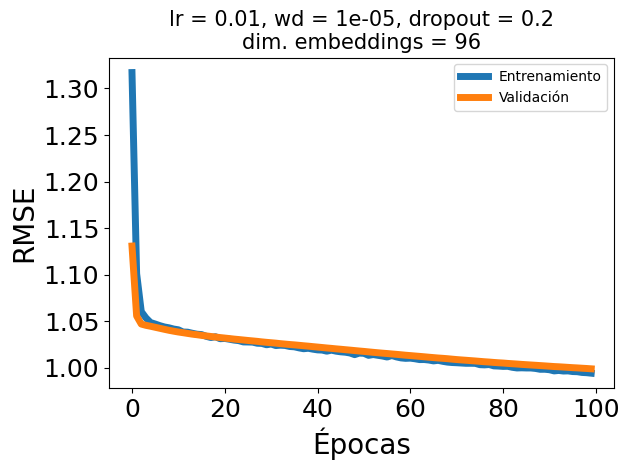

Entrenamiento con parámetros: lr=0.01, wd=1e-05, drop=0.4, época=100, early_stop=15, dim_embed=96
Epoch 5 |Train Loss: 0.045 | Val Loss: 0.043
Epoch 10 |Train Loss: 0.044 | Val Loss: 0.043
Epoch 15 |Train Loss: 0.043 | Val Loss: 0.043
Epoch 20 |Train Loss: 0.043 | Val Loss: 0.042
Epoch 25 |Train Loss: 0.043 | Val Loss: 0.042
Epoch 30 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 35 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 40 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 45 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 50 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 55 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 60 |Train Loss: 0.042 | Val Loss: 0.042
Epoch 65 |Train Loss: 0.042 | Val Loss: 0.041
Epoch 70 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 75 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 80 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 85 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 90 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 95 |Train Loss: 0.041 | Val Loss: 0.041
Epoch 100 |Train Loss: 0.041 

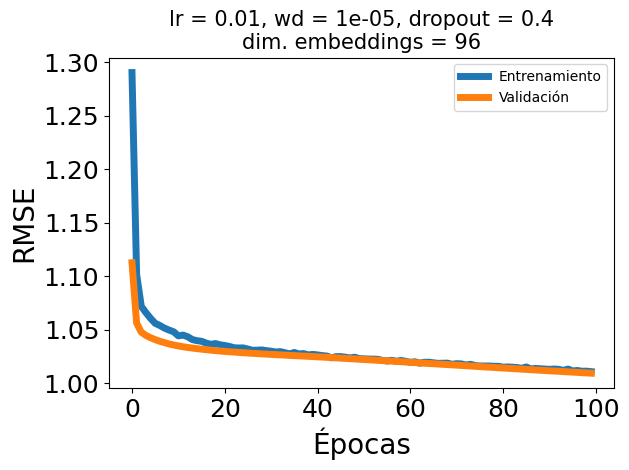

In [18]:
resultados_train =[] 
n=0
for tam_embedd in [32,64,96]:
    for lr in [1e-3,5e-3,1e-2]:
        for wd in [0,1e-2, 1e-5]:
            for drop in [0,0.2,0.4]:
                best_model,best_val, train_graf,val_graf, epoca_parada = entrenaRed(lr=lr,wd=wd, dropout=drop, epoca = 100, early_stop= 15,tam_embedd =tam_embedd)
                
                graf = graficaEntrenamiento(train_graf,val_graf,lr,wd,drop,n,tam_embedd)
                param_train = {
                    "lr":      lr,
                    "wd":      wd,
                    "dropout": drop,
                    "epoca_parada": epoca_parada ,
                    'tam_embeddings':tam_embedd,
                    "best_RMSE_val":best_val,
                    "grafica" : graf
                }
                resultados_train.append(param_train)
                n+=1

Se recopilan los resultados de todas las combinaciones en una tabla, se añade el RMSE en la escala original del rating, y se guarda en un csv.

In [ ]:
tabla_resultados = pd.DataFrame(resultados_train)
tabla_resultados['RMSE_original']= (tabla_resultados['best_RMSE_val']**0.5)*5

tabla_resultados.to_csv("resultadosRNcol.csv", index=False)


Se ordenan las combinaciones de mejor a peor RMSE de validación. La mejor combinación usa dimensión de embedding 96 y RMSE ≈ 0.989.

In [23]:
tabla_resultados.sort_values(['best_RMSE_val'])

,lr,wd,dropout,epoca_parada,tam_embeddings,best_RMSE_val,grafica,RMSE_original
78,0.010,0.00001,0.0,100,96,0.039120,78.png,0.988943
72,0.010,0.00000,0.0,100,96,0.039143,72.png,0.989231
73,0.010,0.00000,0.2,100,96,0.039541,73.png,0.994240
45,0.010,0.00000,0.0,100,64,0.039831,45.png,0.997890
79,0.010,0.00001,0.2,100,96,0.039914,79.png,0.998920
...,...,...,...,...,...,...,...,...
8,0.001,0.00001,0.4,100,32,0.043721,8.png,1.045473
7,0.001,0.00001,0.2,100,32,0.043823,7.png,1.046695
1,0.001,0.00000,0.2,100,32,0.043926,1.png,1.047930
33,0.001,0.00001,0.0,42,64,0.043947,33.png,1.048172


## Reentrenamiento final y evaluación
Con la mejor configuración de hiperparámetros, entrenaRedCompleta reentrena el modelo desde cero usando train+val (dataloader_train_val), esta vez sin conjunto de validación ni early stopping, durante un número fijo de épocas.

In [20]:
def  entrenaRedCompleta(lr,wd,dropout,epoca,embedDim):
    criterion = nn.MSELoss()
    model =NCF(numUsers,numItems,dropout,embedDim) 
    optimizer =optim.SGD(model.parameters(), lr=lr,weight_decay=wd)
    
    for epoch in range(epoca):
        model.train()
        train_loss = 0
        for user, item, y in dataloader_train_val:
            optimizer.zero_grad()
            pred= model(user, item)
            loss = criterion(pred, y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(dataloader_train_val)
        
        if (epoch + 1) %5 ==0:
            print(f"Epoch {epoch+1} |Train Loss: {train_loss:.3f} ")
            
        
    return  model


evaluacion llama a entrenaRedCompleta y, una vez entrenado el modelo final, calcula el RMSE y el MAE sobre el conjunto de test (deshaciendo la normalización, multiplicando por 5).

In [28]:
def evaluacion (lr,wd,dropout,epoca,embedDim):
    final_model = entrenaRedCompleta(lr,wd,dropout,epoca,embedDim)
    
    criterion = nn.MSELoss()
    final_model.eval()
    test_loss = 0
    test_mae = 0
    
    with torch.no_grad():
        for user, item, y in dataloader_test:
            pred = final_model(user,item)
            loss = criterion(pred, y)
            test_loss += loss.item()
            test_mae += torch.abs(pred - y).mean().item()
    mse = test_loss / len(dataloader_test)
    rmse = (mse ** 0.5) * 5.0
    mae = (test_mae / len(dataloader_test)) * 5.0
    print("Test RMSE:", rmse)
    print("Test MAE:", mae)

    return final_model, rmse

Se reentrena y evalúa con lr=0.001, wd=0.00001, dropout=0 y embedDim=96, ejecutándolo dos veces para comprobar la estabilidad del resultado.

In [24]:
# reentranamiento + evaluacion
evaluacion(lr=0.0010, wd=0.00001, dropout=0, epoca=60, embedDim=96)

Epoch 5 |Train Loss: 0.058 
Epoch 10 |Train Loss: 0.049 
Epoch 15 |Train Loss: 0.046 
Epoch 20 |Train Loss: 0.044 
Epoch 25 |Train Loss: 0.044 
Epoch 30 |Train Loss: 0.043 
Epoch 35 |Train Loss: 0.043 
Epoch 40 |Train Loss: 0.043 
Epoch 45 |Train Loss: 0.043 
Epoch 50 |Train Loss: 0.043 
Epoch 55 |Train Loss: 0.043 
Epoch 60 |Train Loss: 0.043 
Test RMSE: 1.0582594616607668


(NCF(
   (user_embedding): Embedding(610, 96)
   (item_embedding): Embedding(9598, 96)
   (fc1): Linear(in_features=192, out_features=64, bias=True)
   (fc2): Linear(in_features=64, out_features=32, bias=True)
   (fc3): Linear(in_features=32, out_features=1, bias=True)
   (relu): ReLU()
   (dropout): Dropout(p=0, inplace=False)
   (sigmoid): Sigmoid()
 ),
 1.0582594616607668)

In [29]:
evaluacion(lr=0.0010, wd=0.00001, dropout=0, epoca=60, embedDim=96)

Epoch 5 |Train Loss: 0.062 
Epoch 10 |Train Loss: 0.049 
Epoch 15 |Train Loss: 0.045 
Epoch 20 |Train Loss: 0.044 
Epoch 25 |Train Loss: 0.044 
Epoch 30 |Train Loss: 0.044 
Epoch 35 |Train Loss: 0.043 
Epoch 40 |Train Loss: 0.043 
Epoch 45 |Train Loss: 0.043 
Epoch 50 |Train Loss: 0.043 
Epoch 55 |Train Loss: 0.043 
Epoch 60 |Train Loss: 0.043 
Test RMSE: 1.058062660570241
Test MAE: 0.8367329880007003


(NCF(
   (user_embedding): Embedding(610, 96)
   (item_embedding): Embedding(9598, 96)
   (fc1): Linear(in_features=192, out_features=64, bias=True)
   (fc2): Linear(in_features=64, out_features=32, bias=True)
   (fc3): Linear(in_features=32, out_features=1, bias=True)
   (relu): ReLU()
   (dropout): Dropout(p=0, inplace=False)
   (sigmoid): Sigmoid()
 ),
 1.058062660570241)